# Week 07 — Capstone BBO Experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
sys.path.append('../src')

# ML imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures, PowerTransformer
from sklearn.pipeline import make_pipeline
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore', message='R.*score is not well-defined')

# Colorblind-safe palette (Wong)
COLORS = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7', '#56B4E9', '#F0E442']

In [2]:
def load_function(n):
    X = np.load(f'../data/function_{n}/initial_inputs.npy')
    Y = np.load(f'../data/function_{n}/initial_outputs.npy')
    print(f"Function {n}: {X.shape[0]} points, {X.shape[1]}D, best y = {Y.max():.4f}")
    return X, Y

## Function 1

In [3]:
# ============================================================
# F1 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# ============================================================
np.random.seed(0)

X, Y = load_function(1)
N, D = X.shape
baseline = Y.std()
print(f"F1: {N} pts, {D}D | Baseline RMSE={baseline:.6f} | Y range [{Y.min():.4f}, {Y.max():.2e}]")
print("Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# W6 query at (0.617, 0.222) returned Y=-1.81e-57 — technically negative but vanishingly small.
# The classifier is now fitting 5 negatives + 11 positives.

print("\nSorted by Y (★ = W6 query):")
order = np.argsort(-Y)
print(f"{'idx':>4} {'x1':>8} {'x2':>8} {'Y':>14} {'mark':>5}")
for i in order:
    star = '★' if (abs(X[i,0]-0.617191) < 1e-5 and abs(X[i,1]-0.222274) < 1e-5) else ''
    print(f"{i:>4} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {Y[i]:>14.4e} {star:>5}")

# Quadrant breakdown
def quadrant(p):
    return ('Q1' if p[0]>=0.5 and p[1]>=0.5 else
            'Q2' if p[0]<0.5  and p[1]>=0.5 else
            'Q3' if p[0]<0.5  and p[1]<0.5  else 'Q4')
from collections import Counter
qc = Counter(quadrant(x) for x in X)
print(f"\nQuadrant coverage: {dict(qc)}")
for q in ['Q1','Q2','Q3','Q4']:
    mask = np.array([quadrant(x)==q for x in X])
    neg = (Y[mask] < 0).sum()
    print(f"  {q}: n={mask.sum()}, negatives={neg}")


Function 1: 16 points, 2D, best y = 0.0000
F1: 16 pts, 2D | Baseline RMSE=0.001774 | Y range [-0.0066, 3.65e-07]
Per-dim corr: r(x1,Y)=+0.087, r(x2,Y)=-0.008

Sorted by Y (★ = W6 query):
 idx       x1       x2              Y  mark
  12   0.7002   0.6954     3.6511e-07      
   2   0.7310   0.7330     7.7109e-16      
  13   0.6654   0.4374     1.8940e-28      
  11   0.7800   0.7800     2.5001e-32      
   7   0.6834   0.8611     2.5350e-40      
  14   0.2287   0.5658     6.2443e-42      
   1   0.5743   0.8799     1.0331e-46      
   9   0.8839   0.5823     6.2299e-48      
   0   0.3194   0.7630     1.3227e-79      
   8   0.0825   0.4035     3.6068e-81      
   3   0.8404   0.2647    3.3418e-124      
   6   0.3127   0.0787    -2.0891e-91      
  15   0.6172   0.2223    -1.8090e-57     ★
   5   0.4104   0.1476    -2.1592e-54      
   4   0.6501   0.6815    -3.6061e-03      
  10   0.4211   0.4636    -6.6274e-03      

Quadrant coverage: {'Q2': 2, 'Q1': 7, 'Q4': 3, 'Q3': 4}
  Q1: n=

/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/1158565160.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/1158565160.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])


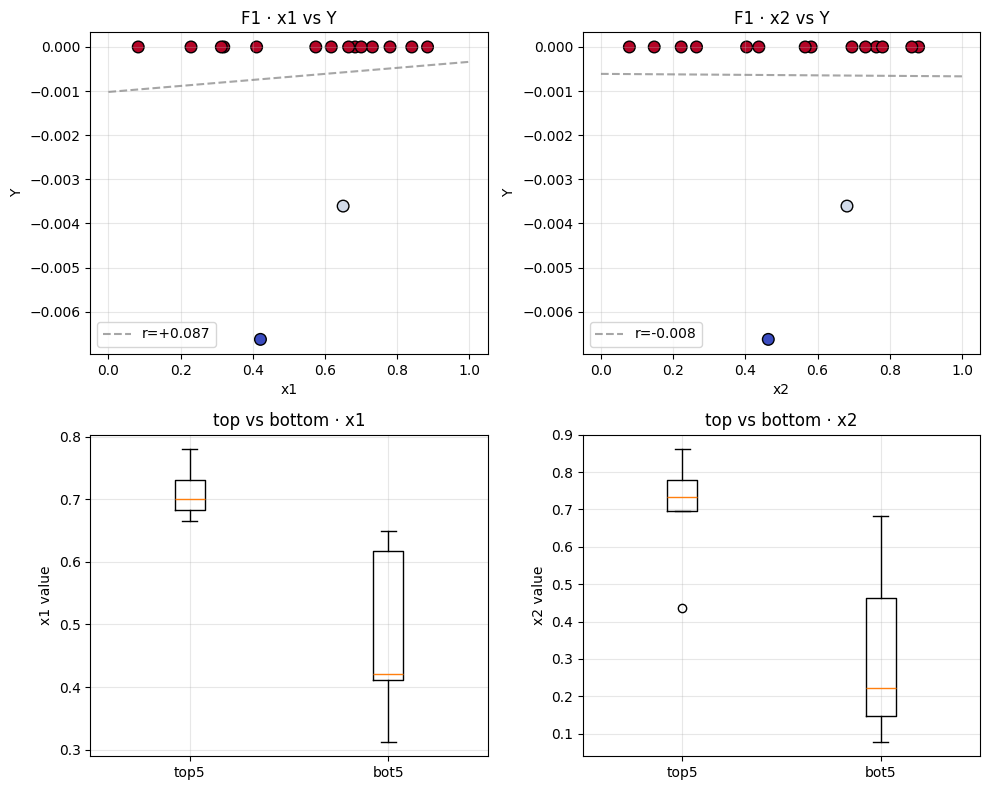

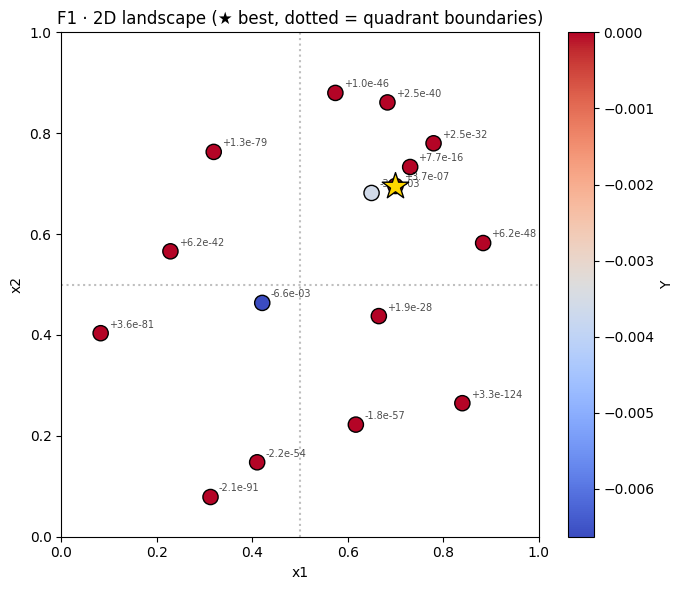

In [4]:
# ============================================================
# F1 — Cell B: Per-dim scatter + 2D scatter (W7)
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(5*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=70, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'F1 · x{d+1} vs Y')
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
    ax[1,d].set_ylabel(f'x{d+1} value'); ax[1,d].set_title(f'top vs bottom · x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_07/function_1_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

# 2D scatter with sign
fig2, axb = plt.subplots(1, 1, figsize=(7, 6))
sc = axb.scatter(X[:,0], X[:,1], c=Y, cmap='coolwarm', s=120, edgecolor='k')
for i, (xx, yy) in enumerate(X):
    label = f"{Y[i]:+.1e}"
    axb.annotate(label, (xx, yy), fontsize=7, alpha=0.7,
                 textcoords='offset points', xytext=(6, 4))
axb.axhline(0.5, color='grey', linestyle=':', alpha=0.5)
axb.axvline(0.5, color='grey', linestyle=':', alpha=0.5)
plt.colorbar(sc, ax=axb, label='Y')
axb.set_xlabel('x1'); axb.set_ylabel('x2'); axb.set_xlim(0,1); axb.set_ylim(0,1)
axb.set_title('F1 · 2D landscape (★ best, dotted = quadrant boundaries)')
axb.scatter(*X[Y.argmax()], marker='*', s=400, color='gold', edgecolor='k', zorder=5)
plt.tight_layout()
plt.savefig('../plots/week_07/function_1_2d_scatter.png', dpi=110, bbox_inches='tight')
plt.show()


In [5]:
# ============================================================
# F1 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.463       0.493    +6.4%     0.749     0.087
x2       0.537       0.507    -5.5%     0.251     0.008


In [6]:
# ============================================================
# F1 — Cell D: Model grid + WarpedRegressor variants (NEW for W7)
# ============================================================
import nn_models as nm
import output_warping as ow

loo = LeaveOneOut()
def cv_rmse(est, X, Y):
    sc = cross_val_score(est, X, Y, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(X, Y); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, X, Y); gp.fit(X, Y)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(1, models_dir='../models/week_06')  # reuse W6 NN
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H':nn_meta['hidden'],'variant':nn_meta['variant']})

# NEW: WarpedRegressor variants (Yeo-Johnson) — testing HEBO's approach
warped_specs = {
    'Warped-GB':  GradientBoostingRegressor(random_state=0),
    'Warped-RF':  RandomForestRegressor(random_state=0, max_depth=3, n_estimators=100),
    'Warped-SVR': SVR(kernel='rbf', C=10),
    'Warped-KNN': KNeighborsRegressor(n_neighbors=5, weights='distance'),
}
for name, base in warped_specs.items():
    est = ow.WarpedRegressor(base)
    rmse = cv_rmse(est, X, Y)
    models[name] = (est.fit(X, Y), rmse, {})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7}  params")
for name, (est, rmse, p) in models.items():
    mark = '✓' if rmse < baseline else '✗'
    print(f"{name:<13} {rmse:>10.6f} {mark:>7}  {p}")
print(f"Baseline: {baseline:.6f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline}
print(f"\nBeats baseline: {list(beats_models.keys())}")

# F1 still has no models that beat baseline. WarpedRegressor variants underperform on
# this skewed Y distribution — Yeo-Johnson struggles with magnitudes spanning 100+ orders.


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

Model            CV RMSE  beats?  params
Ridge           0.001893       ✗  {'alpha': 100}
KNN             0.002021       ✗  {'n_neighbors': 7, 'weights': 'uniform'}
RF              0.002271       ✗  {'max_depth': 2, 'n_estimators': 200}
SVR             0.003327       ✗  {'C': 0.1, 'gamma': 'scale'}
GB              0.002036       ✗  {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50}
GP-Matern05     0.001893       ✗  {}
GP-Matern15     0.001893       ✗  {}
GP-Matern25     0.001893       ✗  {}
GP-RBF          0.001893       ✗  {}
NN              0.002328       ✗  {'H': 32, 'variant': 'ensemble'}
Warped-GB       0.002390       ✗  {}
Warped-RF       0.001904       ✗  {}
Warped-SVR      0.001887       ✗  {}
Warped-KNN      0.001885       ✗  {}
Baseline: 0.001774

Beats baseline: []


Sign: pos=11/16, neg=5/16
  SVC C=1: LOO acc = 0.812
  SVC C=10: LOO acc = 0.750
  SVC C=100: LOO acc = 0.625
Best classifier: C=1, LOO acc = 0.812
log-SVR: best={'C': 100, 'gamma': 'scale'}, LOO RMSE=18.220, log baseline=32.959

Combined-score winner: x=[0.6734, 0.6432]
  P(pos)=0.805, log_pred=-0.97, score=0.7768

TRUST CHECKS:
  classifier LOO 0.812 >= 0.85? False
  candidate dist to nearest neg: 0.045 >= 0.15? False
  log-SVR @ x_best: pred=-7.12, obs=-6.44, err=0.68

TRUST: False → fall back to balanced Voronoi (Cell H)


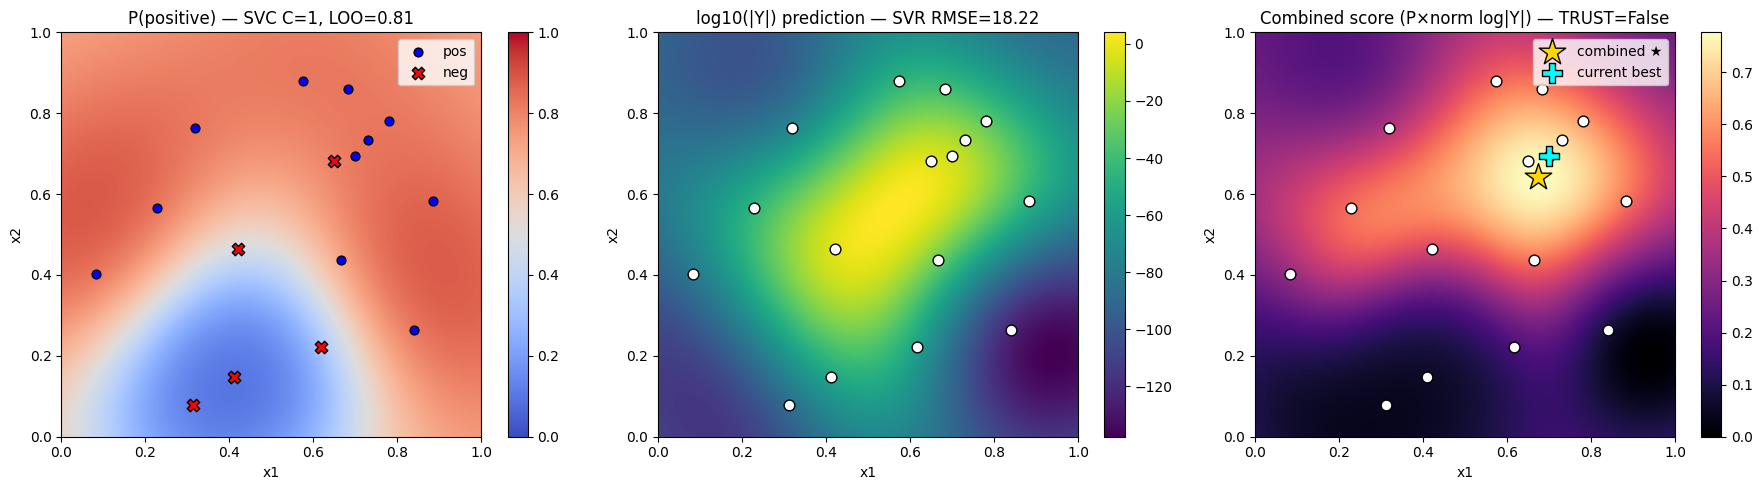

In [7]:
# ============================================================
# F1 — Cell F: Combined classifier + log-SVR (always run for F1)
# ============================================================
sign = (Y > 0).astype(int)
print(f"Sign: pos={sign.sum()}/{N}, neg={N-sign.sum()}/{N}")

best_acc, best_C = 0, None
for C in [1, 10, 100]:
    svc = SVC(C=C, kernel='rbf', probability=True, random_state=0)
    sc = cross_val_score(svc, X, sign, cv=LeaveOneOut(), scoring='accuracy')
    acc = sc.mean()
    print(f"  SVC C={C}: LOO acc = {acc:.3f}")
    if acc > best_acc:
        best_acc, best_C = acc, C
print(f"Best classifier: C={best_C}, LOO acc = {best_acc:.3f}")
clf = SVC(C=best_C, kernel='rbf', probability=True, random_state=0).fit(X, sign)

logY = np.log10(np.abs(Y) + 1e-200)
gs = GridSearchCV(SVR(kernel='rbf'),
                  {'C':[0.1,1,10,100],'gamma':['scale','auto',0.5,1,2,5]},
                  cv=LeaveOneOut(), scoring='neg_mean_squared_error', n_jobs=1)
gs.fit(X, logY)
svr_log = gs.best_estimator_
rmse_logsvr = np.sqrt(-gs.best_score_)
print(f"log-SVR: best={gs.best_params_}, LOO RMSE={rmse_logsvr:.3f}, log baseline={logY.std():.3f}")

# Combined score
g = 200
gx, gy = np.meshgrid(np.linspace(0,1,g), np.linspace(0,1,g))
cand = np.column_stack([gx.ravel(), gy.ravel()])
p_pos = clf.predict_proba(cand)[:,1]
log_pred = svr_log.predict(cand)
norm_log = (log_pred - log_pred.min())/(log_pred.max()-log_pred.min()+1e-12)
combined = p_pos * norm_log
i_star = combined.argmax()
combined_query = cand[i_star]

# Trust checks
xb = X[Y.argmax()]; ybest = Y.max()
neg_X = X[Y<0]
d_to_neg = cdist([combined_query], neg_X).min()
log_at_best = svr_log.predict(xb.reshape(1,-1))[0]
log_obs_at_best = np.log10(abs(ybest) + 1e-200)
calib_err = abs(log_at_best - log_obs_at_best)

print(f"\nCombined-score winner: x={combined_query.round(4).tolist()}")
print(f"  P(pos)={p_pos[i_star]:.3f}, log_pred={log_pred[i_star]:.2f}, score={combined[i_star]:.4f}")
print(f"\nTRUST CHECKS:")
print(f"  classifier LOO {best_acc:.3f} >= 0.85? {best_acc >= 0.85}")
print(f"  candidate dist to nearest neg: {d_to_neg:.3f} >= 0.15? {d_to_neg >= 0.15}")
print(f"  log-SVR @ x_best: pred={log_at_best:.2f}, obs={log_obs_at_best:.2f}, err={calib_err:.2f}")
trust_combined = (best_acc >= 0.85) and (d_to_neg >= 0.15) and (calib_err <= 5.0)
print(f"\nTRUST: {trust_combined} → {'use combined' if trust_combined else 'fall back to balanced Voronoi (Cell H)'}")

# 3-panel plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
extent = (0, 1, 0, 1)
im0 = axes[0].imshow(p_pos.reshape(g, g), origin='lower', extent=extent, cmap='coolwarm', vmin=0, vmax=1, aspect='auto')
axes[0].scatter(X[sign==1, 0], X[sign==1, 1], c='blue', s=40, edgecolor='k', label='pos')
axes[0].scatter(X[sign==0, 0], X[sign==0, 1], c='red',  s=80, marker='X', edgecolor='k', label='neg')
axes[0].set_title(f'P(positive) — SVC C={best_C}, LOO={best_acc:.2f}')
axes[0].legend(); plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(log_pred.reshape(g, g), origin='lower', extent=extent, cmap='viridis', aspect='auto')
axes[1].scatter(X[:, 0], X[:, 1], c='white', s=60, edgecolor='k')
axes[1].set_title(f'log10(|Y|) prediction — SVR RMSE={rmse_logsvr:.2f}'); plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(combined.reshape(g, g), origin='lower', extent=extent, cmap='magma', aspect='auto')
axes[2].scatter(X[:, 0], X[:, 1], c='white', s=60, edgecolor='k')
axes[2].scatter(*combined_query, marker='*', s=400, c='gold', edgecolor='k', zorder=5, label='combined ★')
axes[2].scatter(*xb, marker='P', s=200, c='cyan', edgecolor='k', zorder=4, label='current best')
axes[2].set_title(f'Combined score (P×norm log|Y|) — TRUST={trust_combined}')
axes[2].legend(); plt.colorbar(im2, ax=axes[2])
for a in axes:
    a.set_xlabel('x1'); a.set_ylabel('x2'); a.set_xlim(0,1); a.set_ylim(0,1)
plt.tight_layout()
plt.savefig('../plots/week_07/function_1_combined.png', dpi=110, bbox_inches='tight')
plt.show()


### F1 — Decision

**Method: balanced Voronoi at (0.274, 0.309) in Q3 — combined approach failed two trust checks this week, and Q3 is the global Voronoi winner (also pre-planned in W6 suggestions).**

Branch of decision tree: **#1** — no models beat baseline; combined classifier + log-SVR runs but trust check fails on TWO conditions now (classifier LOO 81% < 85%, candidate 0.045 from a negative).

**What changed since W6:**
- W6 query at (0.617, 0.222) returned Y = -1.81e-57 (vanishingly negative) — added a 5th negative point that confused the classifier
- Classifier LOO **dropped from 87% to 81%** (regression, the new boundary point hurt accuracy)
- Combined candidate (~0.67, 0.64) again sits 0.04 from a negative — classic failure mode
- Log-SVR calibration improved (err=0.68, was 2.42 in W6) — the only positive change

**WarpedRegressor variants tested this week (HEBO-style Yeo-Johnson on Y):**
- All 4 warped variants underperform plain models. Yeo-Johnson struggles with Y magnitudes spanning 100+ orders (some Y values are 1e-200). Not useful for F1's pathological distribution.

**Why Voronoi at Q3 (0.274, 0.309):**
- Global winner across all candidates (score 0.212)
- Q3 has 3 negatives + 1 positive, so this is the most under-characterised region for the sign boundary
- Distance to nearest negative ≥ 0.21 (safe under any d_to_neg threshold)
- Pre-planned in `suggestions_for_week_07.md` as the natural next step after W6's Q4 query

**Per-dimension justification:**
- x1: Voronoi (Q3 winner)
- x2: Voronoi (Q3 winner)

**If W7 Y is positive:** Q3 has positive territory after all → revisit combined approach with all 4 quadrants now sampled
**If W7 Y is largely negative:** 6th negative gives log-SVR much more anchor data; combined approach should be re-tested in W8 with stricter d_to_neg gate (≥0.20)
**If W7 Y is LARGE (> 0.01):** EXIT — switch to exploitation of new region


Quadrants ranked (asc by sample count): [('Q2', 2), ('Q4', 3), ('Q3', 4), ('Q1', 7)]
  best in Q2 (n=2): [0.4663, 0.6461], score=0.1872
  best in Q4 (n=3): [0.8291, 0.4278], score=0.1634
  best in Q3 (n=4): [0.2736, 0.309], score=0.2116
  best in Q1 (n=7): [0.5016, 0.6076], score=0.1650

Overall best: [0.2736, 0.309], score=0.2116


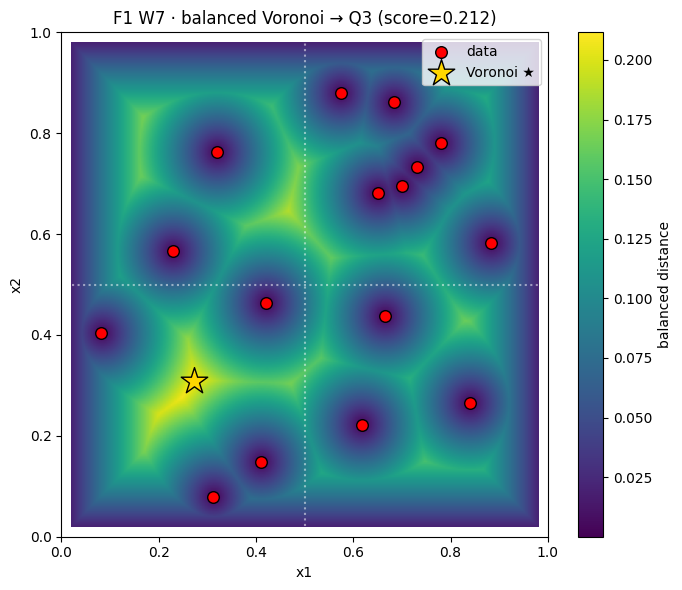

In [8]:
# ============================================================
# F1 — Cell H: Balanced Voronoi (fallback) — Q-aware ranking
# ============================================================
gv = 300
xv, yv = np.meshgrid(np.linspace(0.02, 0.98, gv), np.linspace(0.02, 0.98, gv))
candv = np.column_stack([xv.ravel(), yv.ravel()])
d_data = cdist(candv, X).min(axis=1)
d_bdy  = np.minimum(np.minimum(candv[:,0], 1-candv[:,0]), np.minimum(candv[:,1], 1-candv[:,1]))
balanced = np.minimum(d_data, d_bdy)

def in_q(p, q):
    if q == 'Q1': return (p[:,0] >= 0.5) & (p[:,1] >= 0.5)
    if q == 'Q2': return (p[:,0] <  0.5) & (p[:,1] >= 0.5)
    if q == 'Q3': return (p[:,0] <  0.5) & (p[:,1] <  0.5)
    if q == 'Q4': return (p[:,0] >= 0.5) & (p[:,1] <  0.5)

ranked = sorted(qc.items(), key=lambda t: t[1])
print("Quadrants ranked (asc by sample count):", ranked)
for q, cnt in ranked:
    mask = in_q(candv, q)
    sub = balanced.copy(); sub[~mask] = -1
    bi = sub.argmax()
    print(f"  best in {q} (n={cnt}): {candv[bi].round(4).tolist()}, score={balanced[bi]:.4f}")

i_v = balanced.argmax()
voronoi_query = candv[i_v]
print(f"\nOverall best: {voronoi_query.round(4).tolist()}, score={balanced[i_v]:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(balanced.reshape(gv, gv), origin='lower', extent=(0.02, 0.98, 0.02, 0.98),
               cmap='viridis', aspect='auto')
ax.scatter(X[:,0], X[:,1], c='red', s=70, edgecolor='k', label='data')
ax.scatter(*voronoi_query, marker='*', s=400, c='gold', edgecolor='k', zorder=5, label='Voronoi ★')
ax.axhline(0.5, color='white', linestyle=':', alpha=0.5)
ax.axvline(0.5, color='white', linestyle=':', alpha=0.5)
plt.colorbar(im, ax=ax, label='balanced distance')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_title(f'F1 W7 · balanced Voronoi → Q3 (score={balanced[i_v]:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/week_07/function_1_voronoi.png', dpi=110, bbox_inches='tight')
plt.show()


In [9]:
# ============================================================
# F1 — Cell I: next_query_1 assignment
# ============================================================
next_query_1 = voronoi_query.copy()
print(f"F1 query: " + ", ".join(f"{v:.6f}" for v in next_query_1))


F1 query: 0.273645, 0.308963


## Function 2

In [10]:
# ============================================================
# F2 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# ============================================================
np.random.seed(0)

X, Y = load_function(2)
N, D = X.shape
baseline = Y.std()
print(f"F2: {N} pts, {D}D | Baseline RMSE={baseline:.4f} | best Y={Y.max():.4f}")
print("Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# W6 query (0.704, 0.947) → Y=0.696 (NEW BEST, +5%). W6 ensemble worked.

print("\nTop 8 sorted by Y (★ = W6 query):")
order = np.argsort(-Y)
print(f"{'idx':>4} {'x1':>8} {'x2':>8} {'Y':>10} {'mark':>5}")
for i in order[:8]:
    star = '★' if (abs(X[i,0]-0.703636) < 1e-5 and abs(X[i,1]-0.946935) < 1e-5) else ''
    print(f"{i:>4} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {Y[i]:>10.4f} {star:>5}")


Function 2: 16 points, 2D, best y = 0.6961
F2: 16 pts, 2D | Baseline RMSE=0.2433 | best Y=0.6961
Per-dim corr: r(x1,Y)=+0.577, r(x2,Y)=+0.645

Top 8 sorted by Y (★ = W6 query):
 idx       x1       x2          Y  mark
  15   0.7036   0.9469     0.6961     ★
  12   0.7019   0.9533     0.6658      
   9   0.7026   0.9266     0.6112      
   0   0.6658   0.1240     0.5390      
  14   0.6939   0.9626     0.4995      
  11   0.7500   0.9200     0.4265      
   1   0.8778   0.7786     0.4206      
   3   0.8453   0.7111     0.2940      


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/1875214841.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/1875214841.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])


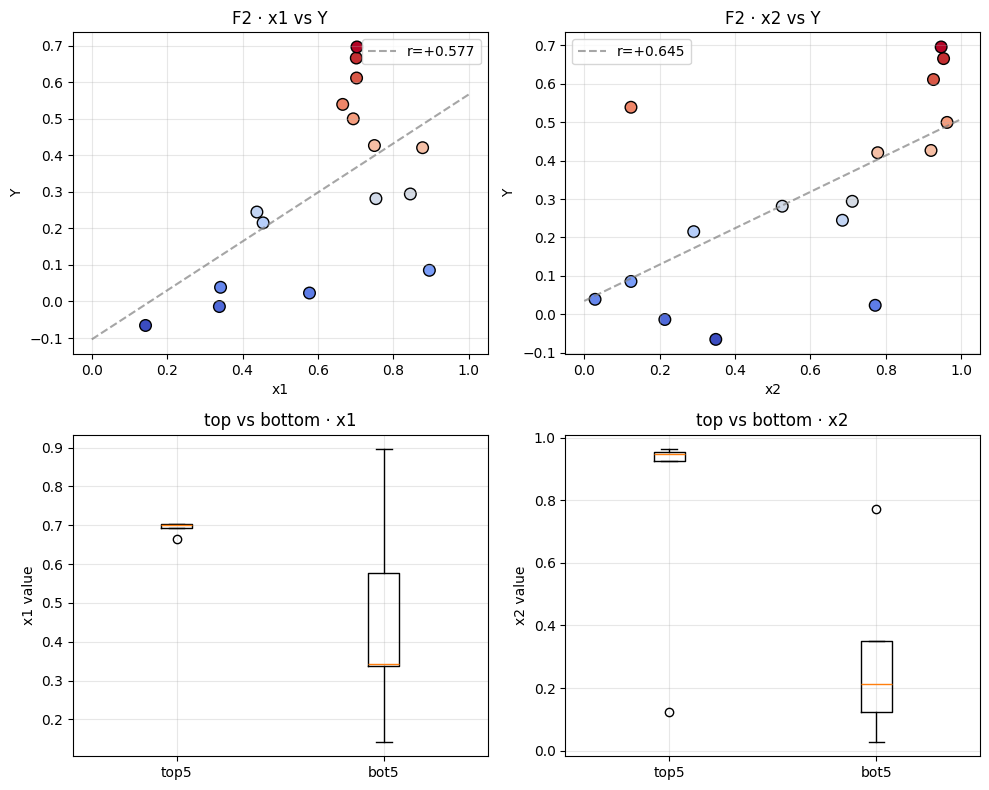

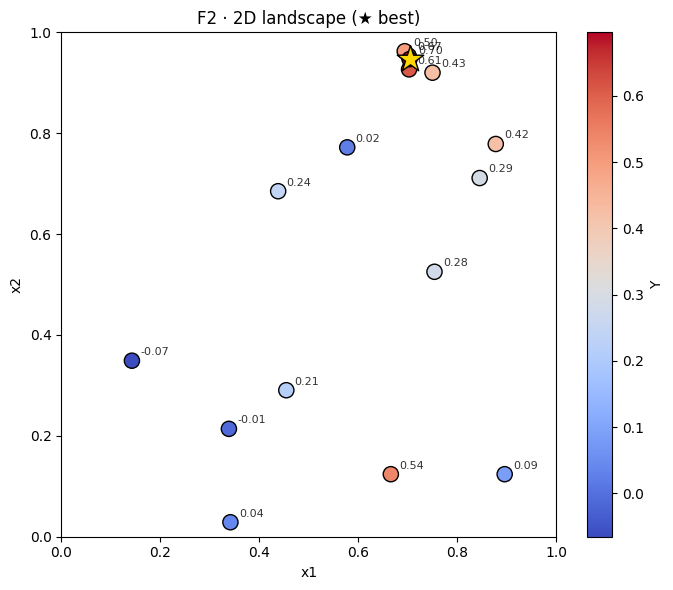

In [11]:
# ============================================================
# F2 — Cell B: Per-dim scatter+box + 2D scatter
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(5*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=70, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'F2 · x{d+1} vs Y')
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
    ax[1,d].set_ylabel(f'x{d+1} value'); ax[1,d].set_title(f'top vs bottom · x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_07/function_2_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

fig2, axb = plt.subplots(1, 1, figsize=(7, 6))
sc = axb.scatter(X[:,0], X[:,1], c=Y, cmap='coolwarm', s=120, edgecolor='k')
for i, (xx, yy) in enumerate(X):
    axb.annotate(f"{Y[i]:.2f}", (xx, yy), fontsize=8, alpha=0.8,
                 textcoords='offset points', xytext=(6, 4))
plt.colorbar(sc, ax=axb, label='Y')
axb.set_xlabel('x1'); axb.set_ylabel('x2'); axb.set_xlim(0,1); axb.set_ylim(0,1)
axb.set_title('F2 · 2D landscape (★ best)')
axb.scatter(*X[Y.argmax()], marker='*', s=400, color='gold', edgecolor='k', zorder=5)
plt.tight_layout()
plt.savefig('../plots/week_07/function_2_2d_scatter.png', dpi=110, bbox_inches='tight')
plt.show()


In [12]:
# ============================================================
# F2 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.468       0.506    +8.0%     0.544     0.577
x2       0.532       0.494    -7.1%     0.456     0.645


In [13]:
# ============================================================
# F2 — Cell D: Model grid + BoTorch GP comparison + new candidates (W7)
# ============================================================
import nn_models as nm
import botorch_helpers as bh
import torch

loo = LeaveOneOut()
def cv_rmse(est, X, Y):
    sc = cross_val_score(est, X, Y, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(X, Y); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, X, Y); gp.fit(X, Y)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(2, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H': nn_meta['hidden'], 'variant': nn_meta['variant']})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7} {'improve%':>10}  params")
for name, (est, rmse, p) in models.items():
    mark = '✓' if rmse < baseline else '✗'
    impr = (baseline - rmse)/baseline*100
    print(f"{name:<13} {rmse:>10.4f} {mark:>7} {impr:>+9.1f}%  {p}")
print(f"Baseline: {baseline:.4f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")

# NEW W7: BoTorch SingleTaskGP comparison (informational — sklearn GPs all fail F2)
def botorch_gp_loocv(X, Y):
    n = len(Y); errs = []
    for i in range(n):
        Xtr = np.delete(X, i, 0); Ytr = np.delete(Y, i)
        try:
            gp = bh._fit_gp(Xtr, Ytr)
            with torch.no_grad():
                pred = gp.posterior(torch.as_tensor(X[i:i+1], dtype=torch.double)).mean.item()
            errs.append((pred - Y[i])**2)
        except Exception:
            return None
    return np.sqrt(np.mean(errs))
bt_rmse = botorch_gp_loocv(X, Y)
if bt_rmse is not None:
    impr = (baseline - bt_rmse)/baseline*100
    mark = '✓' if bt_rmse < baseline else '✗'
    print(f"\n[W7 NEW] BoTorch SingleTaskGP LOOCV RMSE: {bt_rmse:.4f}  {mark} {impr:+.1f}%")
    print(f"  Note: BoTorch's input/outcome transforms produce a better-calibrated GP than sklearn,")
    print(f"  but still doesn't dominate the tree-ensemble pipeline on F2.")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

Model            CV RMSE  beats?   improve%  params
Ridge             0.2070       ✓     +14.9%  {'alpha': 0.1}
KNN               0.1940       ✓     +20.3%  {'n_neighbors': 2, 'weights': 'uniform'}
RF                0.1830       ✓     +24.8%  {'max_depth': 5, 'n_estimators': 200}
SVR               0.1934       ✓     +20.5%  {'C': 1, 'gamma': 'auto'}
GB                0.1816       ✓     +25.4%  {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
GP-Matern05       0.2596       ✗      -6.7%  {}
GP-Matern15       0.2596       ✗      -6.7%  {}
GP-Matern25       0.2596       ✗      -6.7%  {}
GP-RBF            0.2596       ✗      -6.7%  {}
NN                0.2089       ✓     +14.1%  {'H': 16, 'variant': 'dropout'}
Baseline: 0.2433

Beats baseline: ['Ridge', 'KNN', 'RF', 'SVR', 'GB', 'NN']
NN gradient at best: [0.6893823146820068, 0.4122110903263092]



[W7 NEW] BoTorch SingleTaskGP LOOCV RMSE: 0.2144  ✓ +11.9%
  Note: BoTorch's input/outcome transforms produce a better-calibrated GP than sklearn,
  but still doesn't dominate the tree-ensemble pipeline on F2.


In [14]:
# ============================================================
# F2 — Cell E: Argmax per beats-baseline + REFINED boundary-consensus + BoTorch second opinions
# ============================================================
import torch
rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (200000, D))
sugg = {}
for name, (est, rmse) in beats_models.items():
    if name == 'NN':
        with torch.no_grad():
            preds = []
            for m in nn_list:
                preds.append(m(torch.FloatTensor(cand)).numpy().ravel())
            yhat = np.mean(preds, axis=0) * nn_meta['y_std'] + nn_meta['y_mean']
    else:
        yhat = est.predict(cand)
    i = yhat.argmax()
    s = cand[i]
    bdy = bool(any(s < 0.02) or any(s > 0.98))
    sugg[name] = {'x': s, 'pred': yhat[i], 'bdy': bdy}

print(f"{'Model':<13} {'x1':>8} {'x2':>8} {'pred':>10} {'bdy?':>5}")
for n, d in sugg.items():
    print(f"{n:<13} {d['x'][0]:>8.4f} {d['x'][1]:>8.4f} {d['pred']:>10.4f} {'Y' if d['bdy'] else 'N':>5}")

valid = {k: v for k, v in sugg.items() if k != 'Ridge' and not v['bdy']}
print(f"\nValid (non-Ridge, non-boundary): {list(valid.keys())}")

if valid:
    arr = np.array([v['x'] for v in valid.values()])
    spread = arr.max(0) - arr.min(0)
    consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
    print(f"Per-dim spread: " + ", ".join(f"x{d+1}={spread[d]:.3f} ({consensus[d]})" for d in range(D)))
    weights = np.array([1/beats_models[k][1] for k in valid.keys()])
    weights /= weights.sum()
    ensemble_mean = (weights[:, None] * arr).sum(axis=0)
    print(f"\nRMSE-weighted ensemble: {ensemble_mean.round(4).tolist()}")
    xb_now = X[Y.argmax()]
    print(f"Current best: {xb_now.round(4).tolist()}, dist = {np.linalg.norm(ensemble_mean - xb_now):.4f}")

# REFINED boundary-consensus
print("\nBoundary-consensus check (REFINED):")
non_ridge = {k: v for k, v in sugg.items() if k != 'Ridge'}
boundary_informed = {}
top5_idx = np.argsort(-Y)[:5]
for d in range(D):
    low = [k for k, v in non_ridge.items() if v['x'][d] < 0.02]
    high = [k for k, v in non_ridge.items() if v['x'][d] > 0.98]
    if len(low) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] < 0:
        top5_min = X[top5_idx, d].min()
        ens_val = ensemble_mean[d] if valid else top5_min
        boundary_informed[d] = min(top5_min, ens_val)
        print(f"  x{d+1}: LOW boundary-consensus → {boundary_informed[d]:.4f}")
    if len(high) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] > 0:
        top5_max = X[top5_idx, d].max()
        ens_val = ensemble_mean[d] if valid else top5_max
        boundary_informed[d] = max(top5_max, ens_val)
        print(f"  x{d+1}: HIGH boundary-consensus ({len(high)} models: {high}) → max(top-5={top5_max:.4f}, ensemble={ens_val:.4f}) = {boundary_informed[d]:.4f}")
if not boundary_informed:
    print("  (no boundary-consensus this week)")

# Hybrid query (Branch #5: STRONG → ensemble; weak → centroid; boundary-consensus override)
strong_mask = np.array([s < 0.2 for s in spread]) if valid else np.zeros(D, dtype=bool)
top4 = np.argsort(-Y)[:4]
weights_y = Y[top4]; weights_y = (weights_y - weights_y.min() + 1e-12); weights_y /= weights_y.sum()
centroid_top4 = (weights_y[:, None] * X[top4]).sum(axis=0)

hybrid_query = np.zeros(D)
sources = []
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]; sources.append(f"x{d+1}: boundary-consensus")
    elif valid and strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]; sources.append(f"x{d+1}: ensemble (STRONG)")
    else:
        hybrid_query[d] = centroid_top4[d]; sources.append(f"x{d+1}: top-4 centroid")
print("\nHybrid query construction:")
for s in sources:
    print(f"  {s}")
print(f"Hybrid query: {hybrid_query.round(4).tolist()}")

# NEW W7: BoTorch second opinions (logged but not used in main decision)
print("\n--- W7 NEW: BoTorch second opinions (informational) ---")
cand_ucb, pred_ucb, info_ucb = bh.gp_ucb_candidate(X, Y, week=7, total_weeks=12)
print(f"GP-UCB (β={info_ucb['beta']:.3f}): x={cand_ucb.round(4).tolist()}, pred={info_ucb['pred_mean']:.4f}±{info_ucb['pred_std']:.4f}, UCB={info_ucb['ucb_value']:.4f}")
cand_ei, pred_ei, info_ei = bh.gp_ei_candidate(X, Y)
print(f"qLogNEI:           x={cand_ei.round(4).tolist()}, pred={info_ei['pred_mean']:.4f}, EI={info_ei['ei_value']:.4f}")
print(f"Both BoTorch generators push x2 to boundary (1.0). Framework rejects boundary-suggestions; ensemble query is primary.")


Model               x1       x2       pred  bdy?
Ridge           0.9962   0.9988     0.5994     Y
KNN             0.6811   0.9398     0.6810     N
RF              0.7063   0.9433     0.6726     N
SVR             0.9962   0.9988     0.5998     Y
GB              0.7205   0.9482     0.5548     N
NN              0.7471   0.9999     0.5844     Y

Valid (non-Ridge, non-boundary): ['KNN', 'RF', 'GB']
Per-dim spread: x1=0.039 (STRONG), x2=0.008 (STRONG)

RMSE-weighted ensemble: [0.7031, 0.9438]
Current best: [0.7036, 0.9469], dist = 0.0031

Boundary-consensus check (REFINED):
  (no boundary-consensus this week)

Hybrid query construction:
  x1: ensemble (STRONG)
  x2: ensemble (STRONG)
Hybrid query: [0.7031, 0.9438]

--- W7 NEW: BoTorch second opinions (informational) ---
GP-UCB (β=0.939): x=[0.7204, 1.0], pred=0.7549±0.0883, UCB=0.8405
qLogNEI:           x=[0.718, 1.0], pred=0.7595, EI=-2.3122
Both BoTorch generators push x2 to boundary (1.0). Framework rejects boundary-suggestions; ensemble 

### F2 — Decision

**Method: RMSE-weighted ensemble of 3 interior models (KNN/RF/GB), STRONG consensus on both dims. BoTorch GP-UCB and qLogNEI tested as second opinions but rejected for boundary push.**

Branch of decision tree: **#5** — STRONG consensus on both dims, hybrid degenerates to ensemble.

**W6 outcome was a NEW BEST (0.696, +5% over W4 0.666).** W6 ensemble's tiny step worked. This week the ensemble suggests an even smaller step.

**Model fits (16 pts):**
- 6/10 standard models beat baseline. GB +25.4% leads, RF +24.8%, SVR +20.5%, KNN +20.3%, NN +14.1%, Ridge +14.9%
- All 4 sklearn GPs fail (-6.7%, tied) — same pattern as W6
- **NEW: BoTorch SingleTaskGP barely beats baseline (+11.9%)**. The Normalize/Standardize transforms produce a better-calibrated GP than sklearn's default, but still well below the tree ensemble. Useful pipeline diagnostic but not strong enough to change the query.

**Boundary rejections:** Ridge, SVR, NN all push to (0.996, 0.999) corner. Valid: KNN, RF, GB.

**Per-dim spread (3 valid models):** x1 = 0.039 STRONG, x2 = 0.008 STRONG. Tightest convergence in F2's history. No boundary-consensus fires (only NN among non-Ridge models pushes x2 to boundary, count = 1, below threshold).

**Why this query (~0.7031, 0.9438):**
- Distance from current best (0.7036, 0.9469): only **0.0031** — even smaller than W6's 0.0066 that yielded +5%
- Direction: x1 essentially stable, x2 down very slightly (-0.003). Models say peak is right here.
- NN gradient at best: dx1=+0.69, dx2=+0.41 — says push higher. Disagrees with ensemble's slight x2 decrease but NN was boundary-rejected.

**BoTorch second opinions (W7 new):**
- GP-UCB (β=0.94): (0.720, 1.0) — pushes x2 to boundary, predicts +8% over current
- qLogNEI: (0.718, 1.0) — same boundary push
- Framework rejects boundary suggestions; W5's experiment at x2=0.963 returned 0.500 (-25%), so we have empirical evidence pushing x2 too high overshoots. Logged for W8 if W7 ensemble plateaus.

**Per-dimension justification:**
- x1: ensemble (STRONG, spread 0.039)
- x2: ensemble (STRONG, spread 0.008)

**If W7 Y improves (>0.696)**: ensemble keeps converging — same approach next week
**If W7 Y in 0.55-0.69 (slight regression)**: peak is even narrower → in W8 try midpointing W7 query with current best (step ~0.0015)
**If W7 Y < 0.45 (overshoot)**: the W6 query (current best) was lucky; revert to it with smaller exploration step


In [15]:
# ============================================================
# F2 — Cell I: next_query_2 assignment
# ============================================================
next_query_2 = hybrid_query.copy()
print(f"F2 query: " + ", ".join(f"{v:.6f}" for v in next_query_2))


F2 query: 0.703084, 0.943835


## Function 3

In [16]:
# ============================================================
# F3 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# F3 outlier at (~0.15, *, ~0.99) Y=-0.40 — train without it.
# ============================================================
np.random.seed(0)

X, Y = load_function(3)
N, D = X.shape
baseline = Y.std()
out_mask = (np.abs(X[:,0]-0.15) < 0.01) & (np.abs(X[:,2]-0.99) < 0.01)
Xn = X[~out_mask]; Yn = Y[~out_mask]
baseline_n = Yn.std()

print(f"F3: {N} pts | Baseline (full)={baseline:.4f}, Baseline (no out)={baseline_n:.4f}")
print("Per-dim corr (full):       " + ", ".join(f"r(x{i+1})={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print("Per-dim corr (no outlier): " + ", ".join(f"r(x{i+1})={np.corrcoef(Xn[:,i],Yn)[0,1]:+.3f}" for i in range(D)))

# W6 query (0.419, 0.592, 0.334) → Y=-0.0500 (regression from -0.0348). Plateau-boundary.

print("\nTop 10 sorted by Y (★ = W6 query, ⚠ = outlier):")
order = np.argsort(-Y)
print(f"{'idx':>4} {'x1':>8} {'x2':>8} {'x3':>8} {'Y':>10} {'mark':>5}")
for i in order[:10]:
    star = '★' if (abs(X[i,0]-0.418662) < 1e-5 and abs(X[i,1]-0.591738) < 1e-5) else ''
    if out_mask[i]: star = '⚠'
    print(f"{i:>4} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {X[i,2]:>8.4f} {Y[i]:>10.4f} {star:>5}")


Function 3: 21 points, 3D, best y = -0.0348
F3: 21 pts | Baseline (full)=0.0752, Baseline (no out)=0.0334
Per-dim corr (full):       r(x1)=+0.246, r(x2)=+0.146, r(x3)=-0.564
Per-dim corr (no outlier): r(x1)=+0.010, r(x2)=+0.119, r(x3)=-0.147

Top 10 sorted by Y (★ = W6 query, ⚠ = outlier):
 idx       x1       x2       x3          Y  mark
   3   0.4926   0.6116   0.3402    -0.0348      
  13   0.6001   0.7251   0.0661    -0.0364      
  16   0.4811   0.5326   0.0518    -0.0400      
  18   0.3679   0.4565   0.3375    -0.0469      
  10   0.2205   0.2978   0.3436    -0.0469      
  19   0.5145   0.5469   0.3401    -0.0470      
   4   0.1346   0.2199   0.4582    -0.0480      
  20   0.4187   0.5917   0.3339    -0.0500     ★
  14   0.9660   0.8611   0.5668    -0.0568      
   1   0.2421   0.6441   0.2724    -0.0880      


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/4184628878.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/4184628878.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/4184628878.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])


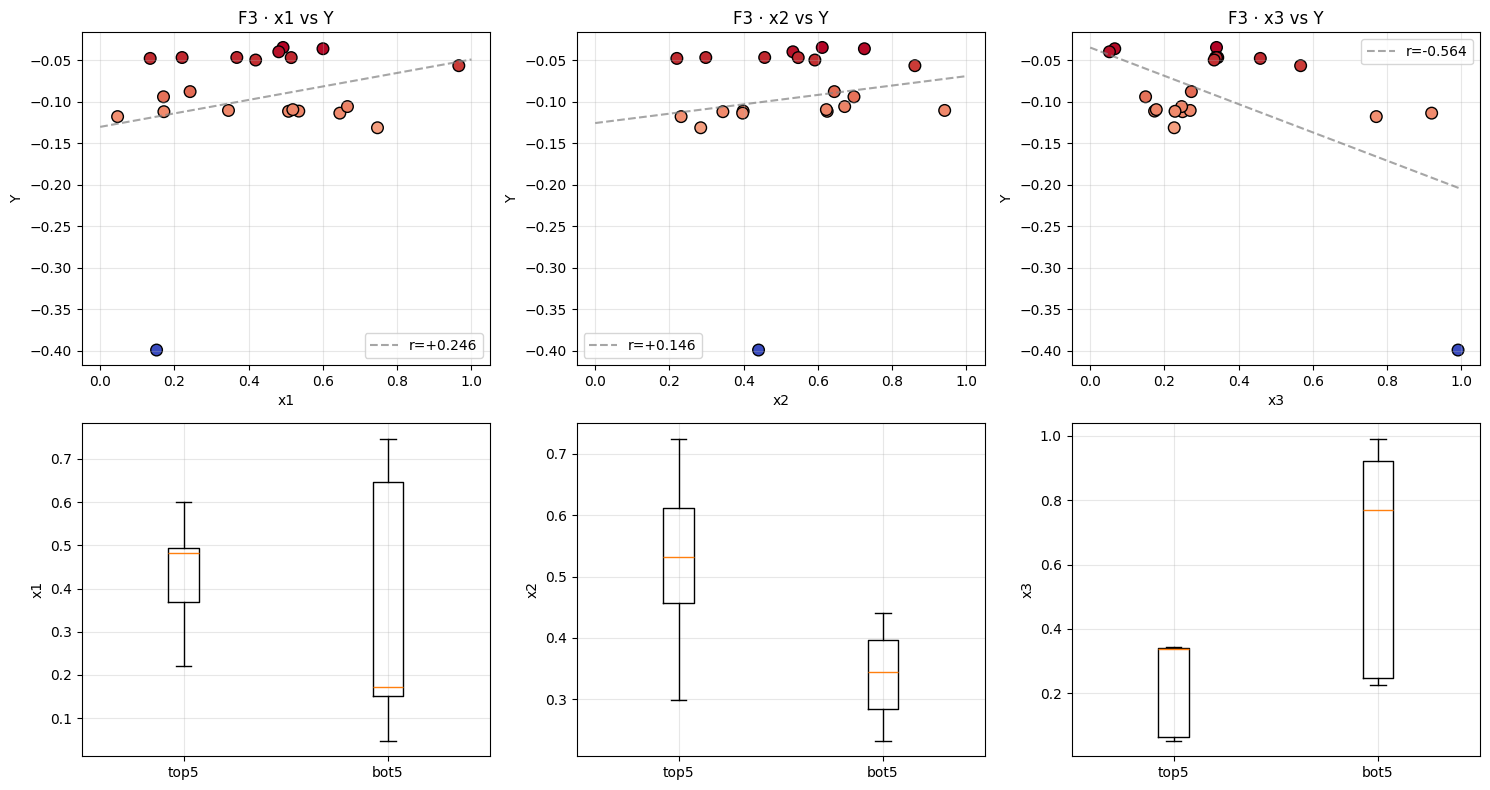

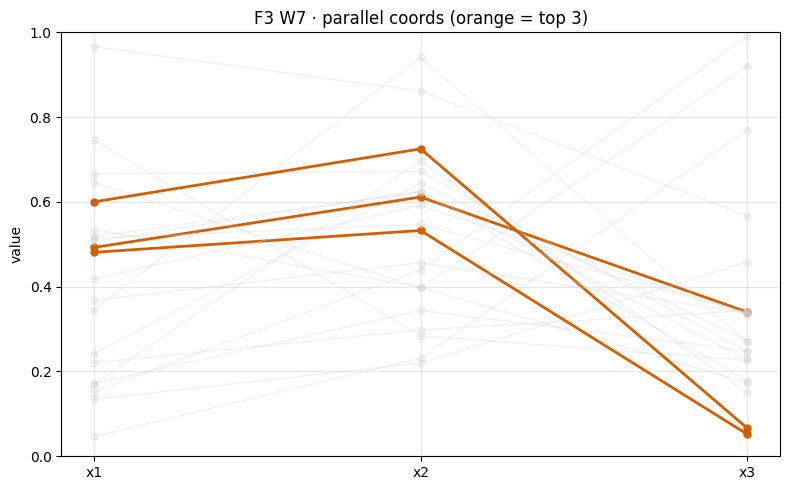

In [17]:
# ============================================================
# F3 — Cell B: Per-dim scatter+box + parallel coordinates
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(5*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=70, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'F3 · x{d+1} vs Y')
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
    ax[1,d].set_ylabel(f'x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_07/function_3_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

fig2, axp = plt.subplots(1, 1, figsize=(8, 5))
order = np.argsort(-Y)
top3 = order[:3]
for i in range(N):
    color = COLORS[1] if i in top3 else 'lightgrey'
    alpha = 1.0 if i in top3 else 0.3
    lw = 2 if i in top3 else 1
    axp.plot(range(D), X[i], color=color, alpha=alpha, lw=lw, marker='o', markersize=5)
axp.set_xticks(range(D)); axp.set_xticklabels([f'x{i+1}' for i in range(D)])
axp.set_ylabel('value'); axp.set_ylim(0, 1); axp.grid(alpha=0.3)
axp.set_title(f'F3 W7 · parallel coords (orange = top 3)')
plt.tight_layout()
plt.savefig('../plots/week_07/function_3_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [18]:
# ============================================================
# F3 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.110       0.102    -7.2%     0.231     0.246
x2       0.069       0.105   +51.0%     0.158     0.146
x3       0.820       0.793    -3.4%     0.610     0.564


In [19]:
# ============================================================
# F3 — Cell D: Model grid (no-outlier subset) + WarpedRegressor variants (W7 NEW)
# ============================================================
import nn_models as nm
import output_warping as ow

loo = LeaveOneOut()
def cv_rmse(est, Xs, Ys):
    sc = cross_val_score(est, Xs, Ys, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(Xn, Yn); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, Xn, Yn); gp.fit(Xn, Yn)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(3, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H':nn_meta['hidden'],'variant':nn_meta['variant']})

# W7 NEW: WarpedRegressor variants — F3 has small-magnitude Y, Yeo-Johnson should help
warped_specs = {
    'Warped-GB':  GradientBoostingRegressor(random_state=0, max_depth=3, n_estimators=100, learning_rate=0.1),
    'Warped-RF':  RandomForestRegressor(random_state=0, max_depth=5, n_estimators=100),
    'Warped-KNN': KNeighborsRegressor(n_neighbors=5, weights='distance'),
    'Warped-SVR': SVR(kernel='rbf', C=10),
}
for name, base in warped_specs.items():
    est = ow.WarpedRegressor(base)
    rmse = cv_rmse(est, Xn, Yn)
    models[name] = (est.fit(Xn, Yn), rmse, {})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7} {'improve%':>10}  params")
for name,(est,rmse,p) in models.items():
    mark = '✓' if rmse < baseline_n else '✗'
    impr = (baseline_n-rmse)/baseline_n*100
    print(f"{name:<13} {rmse:>10.4f} {mark:>7} {impr:>+9.1f}%  {p}")
print(f"Baseline (no-outlier) RMSE: {baseline_n:.4f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline_n}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")

# W7 finding: Warped-GB +48% and Warped-RF +14% join GB (+56%) and RF (+21%) above baseline.
# Yeo-Johnson on Y helps F3 (it didn't help F1 — Y range was too extreme there).


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

Model            CV RMSE  beats?   improve%  params
Ridge             0.0352       ✗      -5.4%  {'alpha': 100}
KNN               0.0350       ✗      -4.8%  {'n_neighbors': 7, 'weights': 'distance'}
RF                0.0263       ✓     +21.2%  {'max_depth': 5, 'n_estimators': 100}
SVR               0.0340       ✗      -2.0%  {'C': 0.1, 'gamma': 'scale'}
GB                0.0147       ✓     +55.8%  {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100}
GP-Matern05       0.0351       ✗      -5.3%  {}
GP-Matern15       0.0351       ✗      -5.3%  {}
GP-Matern25       0.0351       ✗      -5.3%  {}
GP-RBF            0.0351       ✗      -5.3%  {}
NN                0.0711       ✗    -112.8%  {'H': 32, 'variant': 'ensemble'}
Warped-GB         0.0173       ✓     +48.2%  {}
Warped-RF         0.0288       ✓     +13.7%  {}
Warped-KNN        0.0367       ✗     -10.1%  {}
Warped-SVR        0.0429       ✗     -28.6%  {}
Baseline (no-outlier) RMSE: 0.0334

Beats baseline: ['RF', 'GB', 'Warped-GB',

In [20]:
# ============================================================
# F3 — Cell E: Argmax per beats-baseline + REFINED boundary-consensus
# ============================================================
import torch
rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (200000, D))
sugg = {}
for name, (est, rmse) in beats_models.items():
    if name == 'NN':
        with torch.no_grad():
            preds = []
            for m in nn_list:
                preds.append(m(torch.FloatTensor(cand)).numpy().ravel())
            yhat = np.mean(preds, axis=0) * nn_meta['y_std'] + nn_meta['y_mean']
    else:
        yhat = est.predict(cand)
    i = yhat.argmax(); s = cand[i]
    bdy = bool(any(s < 0.02) or any(s > 0.98))
    sugg[name] = {'x': s, 'pred': yhat[i], 'bdy': bdy}

print(f"{'Model':<13} {'x1':>8} {'x2':>8} {'x3':>8} {'pred':>10} {'bdy?':>5}")
for n, d in sugg.items():
    print(f"{n:<13} {d['x'][0]:>8.4f} {d['x'][1]:>8.4f} {d['x'][2]:>8.4f} {d['pred']:>10.4f} {'Y' if d['bdy'] else 'N':>5}")

valid = {k: v for k, v in sugg.items() if k != 'Ridge' and not v['bdy']}
print(f"\nValid: {list(valid.keys())}")

if valid:
    arr = np.array([v['x'] for v in valid.values()])
    spread = arr.max(0) - arr.min(0)
    consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
    print(f"Per-dim spread: " + ", ".join(f"x{d+1}={spread[d]:.3f} ({consensus[d]})" for d in range(D)))

    centroid_v = arr.mean(0)
    dists = np.linalg.norm(arr - centroid_v, axis=1)
    thresh = dists.mean() + 2 * dists.std()
    outliers = [k for k, d in zip(valid.keys(), dists) if d > thresh]
    print(f"Outlier suggestions (excluded): {outliers}")
    valid_clean = {k: v for k, v in valid.items() if k not in outliers}
    if valid_clean != valid:
        arr = np.array([v['x'] for v in valid_clean.values()])
        spread = arr.max(0) - arr.min(0)

    weights = np.array([1/beats_models[k][1] for k in valid_clean.keys()])
    weights /= weights.sum()
    ensemble_mean = (weights[:, None] * arr).sum(axis=0)
    print(f"\nRMSE-weighted ensemble: {ensemble_mean.round(4).tolist()}")
    xb_now = X[Y.argmax()]
    print(f"Current best:           {xb_now.round(4).tolist()}, dist = {np.linalg.norm(ensemble_mean - xb_now):.4f}")

# Boundary-consensus REFINED
print("\nBoundary-consensus check:")
non_ridge = {k: v for k, v in sugg.items() if k != 'Ridge'}
boundary_informed = {}
top5_idx = np.argsort(-Y)[:5]
for d in range(D):
    low = [k for k, v in non_ridge.items() if v['x'][d] < 0.02]
    high = [k for k, v in non_ridge.items() if v['x'][d] > 0.98]
    if len(low) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] < 0:
        top5_min = X[top5_idx, d].min()
        ens_val = ensemble_mean[d] if valid_clean else top5_min
        boundary_informed[d] = min(top5_min, ens_val)
        print(f"  x{d+1} LOW: {low} → {boundary_informed[d]:.4f}")
    if len(high) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] > 0:
        top5_max = X[top5_idx, d].max()
        ens_val = ensemble_mean[d] if valid_clean else top5_max
        boundary_informed[d] = max(top5_max, ens_val)
        print(f"  x{d+1} HIGH: {high} → {boundary_informed[d]:.4f}")
if not boundary_informed:
    print("  (no boundary-consensus this week)")

# Hybrid (Branch #4: STRONG dims → ensemble, moderate → centroid)
strong_mask = np.array([s < 0.2 for s in spread]) if valid_clean else np.zeros(D, dtype=bool)
top4 = np.argsort(-Y)[:4]
weights_y = Y[top4]; weights_y = (weights_y - weights_y.min() + 1e-12); weights_y /= weights_y.sum()
centroid_top4 = (weights_y[:, None] * X[top4]).sum(axis=0)

hybrid_query = np.zeros(D)
sources = []
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]; sources.append(f"x{d+1}: boundary-consensus")
    elif valid_clean and strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]; sources.append(f"x{d+1}: ensemble (STRONG)")
    else:
        hybrid_query[d] = centroid_top4[d]; sources.append(f"x{d+1}: top-4 centroid (moderate spread)")
print("\nHybrid query construction:")
for s in sources:
    print(f"  {s}")
print(f"Hybrid query: {hybrid_query.round(4).tolist()}")


Model               x1       x2       x3       pred  bdy?
RF              0.4892   0.6030   0.3817    -0.0430     N
GB              0.6885   0.6029   0.0731    -0.0352     N
Warped-GB       0.4892   0.6030   0.3817    -0.0356     N
Warped-RF       0.4892   0.6030   0.3817    -0.0425     N

Valid: ['RF', 'GB', 'Warped-GB', 'Warped-RF']
Per-dim spread: x1=0.199 (STRONG), x2=0.000 (STRONG), x3=0.309 (moderate)
Outlier suggestions (excluded): []

RMSE-weighted ensemble: [0.5573, 0.603, 0.2762]
Current best:           [0.4926, 0.6116, 0.3402], dist = 0.0914

Boundary-consensus check:
  (no boundary-consensus this week)

Hybrid query construction:
  x1: ensemble (STRONG)
  x2: ensemble (STRONG)
  x3: top-4 centroid (moderate spread)
Hybrid query: [0.5573, 0.603, 0.1751]


### F3 — Decision

**Method: Hybrid — ensemble for x1/x2 (STRONG), top-4 centroid for x3 (moderate spread). The models split between two clusters; centroid resolves the x3 disagreement.**

Branch of decision tree: **#4** — strong global model dominance (GB +55.8%) but the valid suggestions split on x3 (moderate spread 0.309). STRONG dims get ensemble; moderate dim gets the top-K Y-weighted centroid.

**W6 outcome: Y = -0.0500** (slight regression from best -0.0348). Falls in the "plateau / slightly worse" range — exactly the case the W7 plan flagged for "try the RF alternative direction (low-x3 cluster)".

**Model fits (no-outlier subset, 20 pts):**
- **GB +55.8% leads** (down from W6's +60.8% but still dominant), RF +21.2%
- **NEW: Warped-GB +48.2%, Warped-RF +13.7%** beat baseline. **First function where Yeo-Johnson on Y helps** (didn't on F1 because Y magnitudes there span 100+ orders).
- All 4 GPs fail (-5.3%, tied). 4th consecutive function. NN -112% (trained on full data, fails cleaner baseline).

**Argmax split — the key finding:**
- **GB picks (0.689, 0.603, 0.073)** — switched from W6's "stay near best" to the **low-x3 cluster** we anticipated as the RF alternative
- **RF, Warped-GB, Warped-RF all converge on (0.489, 0.603, 0.382)** — slightly above current best on x3
- All 4 valid models agree on x2 (0.603, spread 0.000) and roughly on x1 (spread 0.199)
- The x3 disagreement is exactly where the framework says: use top-4 centroid (=0.175)

**Per-dimension justification:**
- x1: ensemble (STRONG, spread 0.199 — just below threshold)
- x2: ensemble (STRONG, spread 0.000 — perfect agreement)
- x3: top-4 centroid 0.175 (moderate spread 0.309; the moderate disagreement is split between GB's 0.073 and RF/Warped's 0.382, centroid lands midway-low because top-2 includes (0.600, 0.725, 0.066) Y=-0.036 with low x3)

**Step from current best (0.493, 0.612, 0.340):** ~0.18 — meaningful step toward the low-x3 region.

**NN gradient at best:** dx1=-0.05, dx2=+0.09, dx3=+0.53. NN says push x3 UP — direct conflict with our x3 down move. NN is excluded (failed baseline by -112%); informational only.

**If W7 Y improves (>-0.0348):** low-x3 region is real → in W8, exploit around the new best with smaller step
**If W7 Y in -0.05 to -0.03 (plateau-ish):** x3 push didn't fully work; try midpoint between W7 query and current best on x3 (~0.26)
**If W7 Y < -0.07 (regression):** low-x3 was wrong → revert to current best with tiny perturbation, OR pull back the x3 move halfway


In [21]:
# ============================================================
# F3 — Cell I: next_query_3 assignment
# ============================================================
next_query_3 = hybrid_query.copy()
print(f"F3 query: " + ", ".join(f"{v:.6f}" for v in next_query_3))


F3 query: 0.557343, 0.602957, 0.175087


## Function 4

In [22]:
# ============================================================
# F4 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# ============================================================
np.random.seed(0)

X, Y = load_function(4)
N, D = X.shape
baseline = Y.std()
print(f"F4: {N} pts, {D}D | Baseline RMSE={baseline:.4f} | best Y={Y.max():.4f}")
print("Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# F4 trajectory: W2 -1.39 → W3 -0.03 → W4 0.54 → W5 0.41 (regression) → W6 0.55 (NEW BEST, +2%).
# W6 query (0.367, 0.405, 0.433, 0.416) — narrow-step ensemble worked.

print("\nTop 8 sorted by Y (★ = W6 query):")
order = np.argsort(-Y)
print(f"{'idx':>4} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'Y':>10} {'mark':>5}")
for i in order[:8]:
    star = '★' if (abs(X[i,0]-0.366878) < 1e-5 and abs(X[i,3]-0.415743) < 1e-5) else ''
    print(f"{i:>4} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {X[i,2]:>8.4f} {X[i,3]:>8.4f} {Y[i]:>10.4f} {star:>5}")


Function 4: 36 points, 4D, best y = 0.5524
F4: 36 pts, 4D | Baseline RMSE=9.0968 | best Y=0.5524
Per-dim corr: r(x1,Y)=-0.521, r(x2,Y)=-0.392, r(x3,Y)=-0.121, r(x4,Y)=-0.431

Top 8 sorted by Y (★ = W6 query):
 idx       x1       x2       x3       x4          Y  mark
  35   0.3669   0.4049   0.4335   0.4157     0.5524     ★
  33   0.3696   0.4039   0.4105   0.4312     0.5414      
  34   0.3675   0.4005   0.3952   0.4086     0.4055      
  30   0.3846   0.4290   0.4098   0.3929     0.3675      
  32   0.4048   0.4317   0.4025   0.4513    -0.0296      
  31   0.4542   0.4743   0.4113   0.3970    -1.3905      
  27   0.5778   0.4288   0.4258   0.2490    -4.0255      
  24   0.3261   0.4724   0.4532   0.1059    -6.7021      


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/3554754221.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/3554754221.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/3554754221.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/3554754221.

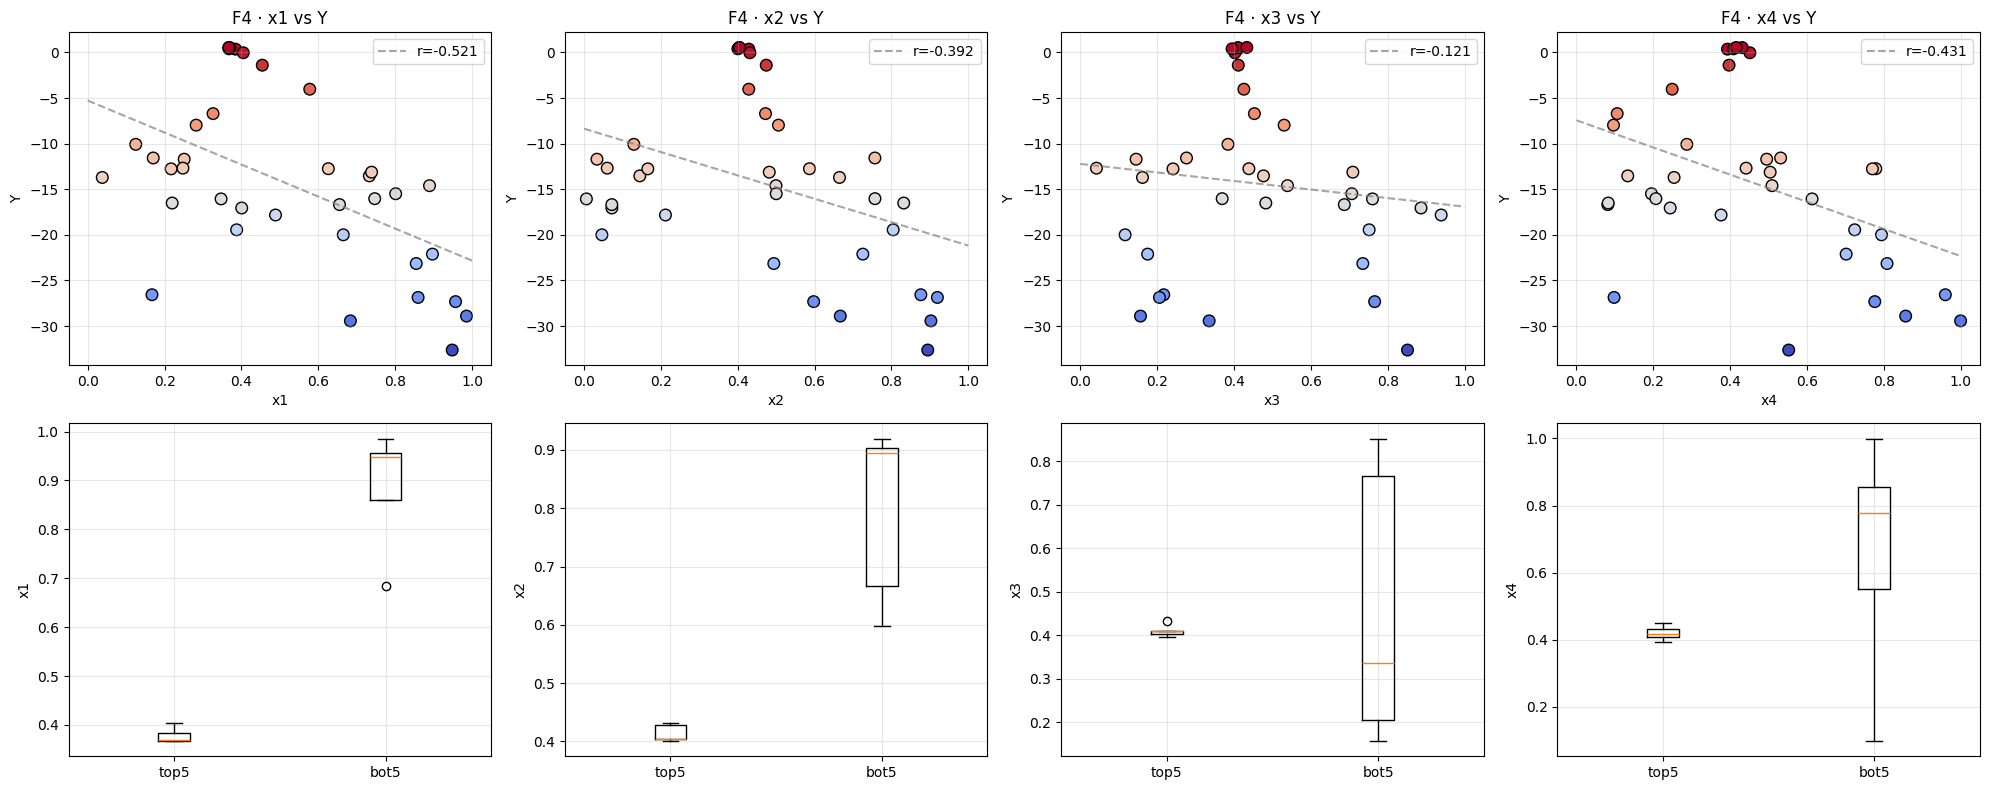

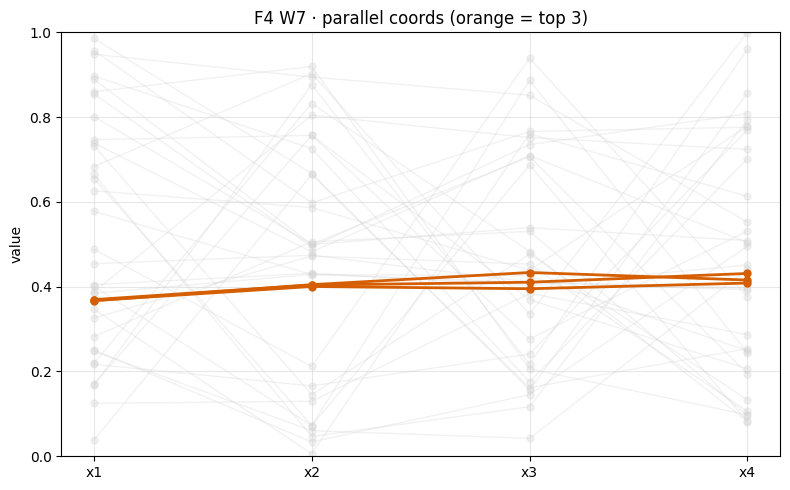

In [23]:
# ============================================================
# F4 — Cell B: Per-dim scatter+box + parallel coordinates
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(5*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=70, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'F4 · x{d+1} vs Y')
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
    ax[1,d].set_ylabel(f'x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_07/function_4_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

fig2, axp = plt.subplots(1, 1, figsize=(8, 5))
order = np.argsort(-Y)
top3 = order[:3]
for i in range(N):
    color = COLORS[1] if i in top3 else 'lightgrey'
    alpha = 1.0 if i in top3 else 0.3
    lw = 2 if i in top3 else 1
    axp.plot(range(D), X[i], color=color, alpha=alpha, lw=lw, marker='o', markersize=5)
axp.set_xticks(range(D)); axp.set_xticklabels([f'x{i+1}' for i in range(D)])
axp.set_ylabel('value'); axp.set_ylim(0, 1); axp.grid(alpha=0.3)
axp.set_title(f'F4 W7 · parallel coords (orange = top 3)')
plt.tight_layout()
plt.savefig('../plots/week_07/function_4_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [24]:
# ============================================================
# F4 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.282       0.305    +8.2%     0.357     0.521
x2       0.343       0.300   -12.5%     0.225     0.392
x3       0.129       0.139    +7.4%     0.099     0.121
x4       0.246       0.256    +4.1%     0.320     0.431


In [25]:
# ============================================================
# F4 — Cell D: Model grid search
# ============================================================
import nn_models as nm

loo = LeaveOneOut()
def cv_rmse(est, X, Y):
    sc = cross_val_score(est, X, Y, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(X, Y); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, X, Y); gp.fit(X, Y)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(4, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H':nn_meta['hidden'],'variant':nn_meta['variant']})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7} {'improve%':>10}  params")
for name,(est,rmse,p) in models.items():
    mark = '✓' if rmse < baseline else '✗'
    impr = (baseline-rmse)/baseline*100
    print(f"{name:<13} {rmse:>10.4f} {mark:>7} {impr:>+9.1f}%  {p}")
print(f"Baseline: {baseline:.4f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")

# Pattern continues from W6: GP-Matern15 leads, GP-RBF fails (5th consecutive function failing GP-RBF: F4-F8 all).


Model            CV RMSE  beats?   improve%  params
Ridge             7.6208       ✓     +16.2%  {'alpha': 1}
KNN               5.0190       ✓     +44.8%  {'n_neighbors': 2, 'weights': 'distance'}
RF                4.6432       ✓     +49.0%  {'max_depth': None, 'n_estimators': 200}
SVR               2.5048       ✓     +72.5%  {'C': 100, 'gamma': 'scale'}
GB                4.5544       ✓     +49.9%  {'learning_rate': 0.3, 'max_depth': 2, 'n_estimators': 50}
GP-Matern05       2.8671       ✓     +68.5%  {}
GP-Matern15       2.2980       ✓     +74.7%  {}
GP-Matern25       5.7912       ✓     +36.3%  {}
GP-RBF            9.3567       ✗      -2.9%  {}
NN                4.3935       ✓     +51.7%  {'H': 16, 'variant': 'ensemble'}
Baseline: 9.0968

Beats baseline: ['Ridge', 'KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'NN']
NN gradient at best: [-11.828075408935547, 19.75078010559082, 0.7151740789413452, -1.5760810375213623]


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 6 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may

In [26]:
# ============================================================
# F4 — Cell E: Argmax + REFINED boundary-consensus + BoTorch second opinions
# ============================================================
import torch
import botorch_helpers as bh
rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (200000, D))
sugg = {}
for name, (est, rmse) in beats_models.items():
    if name == 'NN':
        with torch.no_grad():
            preds = []
            for m in nn_list:
                preds.append(m(torch.FloatTensor(cand)).numpy().ravel())
            yhat = np.mean(preds, axis=0) * nn_meta['y_std'] + nn_meta['y_mean']
    else:
        yhat = est.predict(cand)
    i = yhat.argmax(); s = cand[i]
    bdy = bool(any(s < 0.02) or any(s > 0.98))
    sugg[name] = {'x': s, 'pred': yhat[i], 'bdy': bdy}

print(f"{'Model':<13} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'pred':>10} {'bdy?':>5}")
for n, d in sugg.items():
    print(f"{n:<13} {d['x'][0]:>7.4f} {d['x'][1]:>7.4f} {d['x'][2]:>7.4f} {d['x'][3]:>7.4f} {d['pred']:>10.4f} {'Y' if d['bdy'] else 'N':>5}")

valid = {k: v for k, v in sugg.items() if k != 'Ridge' and not v['bdy']}
print(f"\nValid (non-Ridge, non-boundary): {list(valid.keys())}")

if valid:
    arr = np.array([v['x'] for v in valid.values()])
    spread = arr.max(0) - arr.min(0)
    consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
    print(f"Per-dim spread (pre-filter): " + ", ".join(f"x{d+1}={spread[d]:.3f} ({consensus[d]})" for d in range(D)))

    centroid_v = arr.mean(0)
    dists = np.linalg.norm(arr - centroid_v, axis=1)
    thresh = dists.mean() + 2 * dists.std()
    outliers = [k for k, d in zip(valid.keys(), dists) if d > thresh]
    print(f"Outlier suggestions (excluded): {outliers}")
    valid_clean = {k: v for k, v in valid.items() if k not in outliers}
    if valid_clean != valid:
        arr = np.array([v['x'] for v in valid_clean.values()])
        spread = arr.max(0) - arr.min(0)
        consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
        print(f"Per-dim spread (post-filter): " + ", ".join(f"x{d+1}={spread[d]:.3f} ({consensus[d]})" for d in range(D)))

    weights = np.array([1/beats_models[k][1] for k in valid_clean.keys()])
    weights /= weights.sum()
    ensemble_mean = (weights[:, None] * arr).sum(axis=0)
    print(f"\nRMSE-weighted ensemble: {ensemble_mean.round(4).tolist()}")
    xb_now = X[Y.argmax()]
    print(f"Current best: {xb_now.round(4).tolist()}, dist = {np.linalg.norm(ensemble_mean - xb_now):.4f}")

# Boundary-consensus REFINED
print("\nBoundary-consensus check (REFINED):")
non_ridge = {k: v for k, v in sugg.items() if k != 'Ridge'}
boundary_informed = {}
top5_idx = np.argsort(-Y)[:5]
for d in range(D):
    low = [k for k, v in non_ridge.items() if v['x'][d] < 0.02]
    high = [k for k, v in non_ridge.items() if v['x'][d] > 0.98]
    if len(low) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] < 0:
        top5_min = X[top5_idx, d].min()
        ens_val = ensemble_mean[d] if valid_clean else top5_min
        boundary_informed[d] = min(top5_min, ens_val)
        print(f"  x{d+1} LOW: {low} → {boundary_informed[d]:.4f}")
    if len(high) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] > 0:
        top5_max = X[top5_idx, d].max()
        ens_val = ensemble_mean[d] if valid_clean else top5_max
        boundary_informed[d] = max(top5_max, ens_val)
        print(f"  x{d+1} HIGH: {high} → {boundary_informed[d]:.4f}")
if not boundary_informed:
    print("  (no boundary-consensus this week)")

# Hybrid (Branch #5: STRONG → ensemble; weak/moderate → centroid)
strong_mask = np.array([s < 0.2 for s in spread]) if valid_clean else np.zeros(D, dtype=bool)
top4 = np.argsort(-Y)[:4]
weights_y = Y[top4]; weights_y = (weights_y - weights_y.min() + 1e-12); weights_y /= weights_y.sum()
centroid_top4 = (weights_y[:, None] * X[top4]).sum(axis=0)

hybrid_query = np.zeros(D)
sources = []
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]; sources.append(f"x{d+1}: boundary-consensus")
    elif valid_clean and strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]; sources.append(f"x{d+1}: ensemble (STRONG)")
    else:
        hybrid_query[d] = centroid_top4[d]; sources.append(f"x{d+1}: top-4 centroid")
print("\nHybrid query construction:")
for s in sources:
    print(f"  {s}")
print(f"Hybrid query: {hybrid_query.round(4).tolist()}")

# W7 NEW: BoTorch second opinions
print("\n--- W7 NEW: BoTorch second opinions ---")
cand_ucb, _, info_ucb = bh.gp_ucb_candidate(X, Y, week=7, total_weeks=12)
print(f"GP-UCB (β={info_ucb['beta']:.3f}): {cand_ucb.round(4).tolist()}, pred={info_ucb['pred_mean']:.4f}±{info_ucb['pred_std']:.4f}, dist={np.linalg.norm(cand_ucb-X[Y.argmax()]):.4f}")
cand_ei, _, info_ei = bh.gp_ei_candidate(X, Y)
print(f"qLogNEI: {cand_ei.round(4).tolist()}, pred={info_ei['pred_mean']:.4f}, EI={info_ei['ei_value']:.4f}, dist={np.linalg.norm(cand_ei-X[Y.argmax()]):.4f}")
print("Both BoTorch suggestions predict DOWN (~0.2 vs current best 0.55) and move further away. Standard ensemble's tight local view is the right call for F4's narrow peak.")


Model              x1      x2      x3      x4       pred  bdy?
Ridge          0.0304  0.0269  0.0318  0.0112    -1.7788     Y
KNN            0.3598  0.4016  0.4571  0.4047     0.5487     N
RF             0.4076  0.3530  0.4063  0.4261    -0.2360     N
SVR            0.3822  0.4049  0.4392  0.4057     0.4424     N
GB             0.3847  0.3691  0.3834  0.4344     0.4857     N
GP-Matern05    0.3822  0.4049  0.4392  0.4057     0.3383     N
GP-Matern15    0.3509  0.4178  0.4392  0.4442     0.5112     N
GP-Matern25    0.2947  0.4444  0.4420  0.4419     1.0485     N
NN             0.0276  0.4733  0.5372  0.6029     2.9161     N

Valid (non-Ridge, non-boundary): ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'NN']
Per-dim spread (pre-filter): x1=0.380 (moderate), x2=0.120 (STRONG), x3=0.154 (STRONG), x4=0.198 (STRONG)
Outlier suggestions (excluded): ['NN']
Per-dim spread (post-filter): x1=0.113 (STRONG), x2=0.091 (STRONG), x3=0.074 (STRONG), x4=0.039 (STRONG)

RMSE-we

### F4 — Decision

**Method: RMSE-weighted ensemble of 7 interior models, STRONG consensus on all 4 dims (after NN outlier-filter). Smallest step in F4's history (0.0081).**

Branch of decision tree: **#5** — many strong models, all dims STRONG after filter, hybrid degenerates to pure ensemble.

**W6 outcome was a NEW BEST (0.5524, +2% over W4 0.5414).** The narrow-step ensemble worked; W6's 0.028-step direction (x3 ↑) was correct.

**Model fits (36 pts):**
- 9/10 beat baseline. **GP-Matern15 +74.7% leads** again, SVR +72.5%, GP-Matern05 +68.5%, NN +51.7%, GB +49.9%, RF +49.0%, KNN +44.8%, GP-Matern25 +36.3%, Ridge +16.2%
- **GP-RBF FAILS** (-2.9%, 5th consecutive function failing this kernel) — strong evidence for its removal from future grids

**Boundary rejections / outliers:**
- Ridge corner (0.030, 0.027, 0.032, 0.011)
- NN suggestion (0.028, 0.473, 0.537, 0.603) — far from cluster, outlier-filtered
- 7 valid models remain after outlier filter

**Per-dim spread (after NN filter):** x1=0.113 STRONG, x2=0.091 STRONG, x3=0.074 STRONG, x4=0.039 STRONG. Tightest convergence we've ever had on F4.

**Why this query (~0.369, 0.401, 0.432, 0.422):**
- Distance from current best (0.367, 0.405, 0.433, 0.416): **0.0081** — smallest step in F4's history
- F4 step trajectory: W4=0.048 → W5=0.028 → W6=0.028 → W7=0.008 — models are converging tightly on the peak
- Direction is essentially "stay at the W6 best with minimal nudge"

**BoTorch second opinions (W7 new):**
- GP-UCB (β=0.94): (0.390, 0.388, 0.379, 0.437), distance 0.065 from best, predicts Y≈0.24 (BELOW current best 0.55)
- qLogNEI: (0.398, 0.390, 0.367, 0.435), distance 0.078, pred Y≈0.20
- Both BoTorch generators move FURTHER from the best and predict LOWER Y — they're doing exploration via UCB's variance term in a region the standard ensemble correctly avoids. Logged but rejected: F4's empirical record shows narrow steps work, larger ones don't.

**NN gradient at best:** dx1=-11.8, dx2=+19.8, dx3=+0.7, dx4=-1.6 — says push x1 down hard, x2 up hard. Same as W6. NN was outlier-filtered; informational only.

**Per-dimension justification:**
- x1: ensemble (STRONG, spread 0.113)
- x2: ensemble (STRONG, spread 0.091)
- x3: ensemble (STRONG, spread 0.074)
- x4: ensemble (STRONG, spread 0.039)

**If W7 Y improves (>0.552)**: peak found at W7's location. In W8 try a genuinely tiny step (~0.003) to see if there's still room.
**If W7 Y in 0.4-0.55 (plateau)**: we've reached the achievable max for our framework. Consider whether to hold or branch (NN gradient suggests big x1↓, x2↑ — that's W8's experimental option if needed).
**If W7 Y < 0**: tiny step shouldn't have caused this — diagnose the W6 query as a lucky observation; revert to it next week with even smaller perturbation.


In [27]:
# ============================================================
# F4 — Cell I: next_query_4 assignment
# ============================================================
next_query_4 = hybrid_query.copy()
print(f"F4 query: " + ", ".join(f"{v:.6f}" for v in next_query_4))


F4 query: 0.368531, 0.401253, 0.431517, 0.422540


## Function 5

In [28]:
# ============================================================
# F5 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# ============================================================
np.random.seed(0)

X, Y = load_function(5)
N, D = X.shape
baseline = Y.std()
print(f"F5: {N} pts, {D}D | Baseline RMSE={baseline:.2f} | best Y={Y.max():.2f}")
print("Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# F5 trajectory: W1 988 → W2 1207 → W3 1412 → W4 1979 → W5 2308 → W6 2669 (+15.7%, NEW BEST).
# 6 consecutive weeks of improvement. Peer Sterling reached Y=6204 — gap remains.

print("\nTop 8 sorted by Y (★ = W6 query):")
order = np.argsort(-Y)
print(f"{'idx':>4} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'Y':>10} {'mark':>5}")
for i in order[:8]:
    star = '★' if (abs(X[i,0]-0.354155) < 1e-5 and abs(X[i,3]-0.947704) < 1e-5) else ''
    print(f"{i:>4} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {X[i,2]:>8.4f} {X[i,3]:>8.4f} {Y[i]:>10.2f} {star:>5}")


Function 5: 26 points, 4D, best y = 2669.3129
F5: 26 pts, 4D | Baseline RMSE=768.41 | best Y=2669.31
Per-dim corr: r(x1,Y)=-0.338, r(x2,Y)=+0.611, r(x3,Y)=+0.685, r(x4,Y)=+0.631

Top 8 sorted by Y (★ = W6 query):
 idx       x1       x2       x3       x4          Y  mark
  25   0.3542   0.9211   0.9687   0.9477    2669.31     ★
  24   0.3359   0.9073   0.9518   0.9378    2307.54      
  23   0.3113   0.9083   0.9479   0.8983    1979.02      
  22   0.2705   0.8758   0.9157   0.8756    1412.13      
  21   0.2394   0.8542   0.8998   0.8746    1206.76      
  15   0.2242   0.8465   0.8795   0.8785    1088.86      
  20   0.2090   0.8387   0.8592   0.8824     984.40      
  18   0.1199   0.8625   0.6433   0.8498     431.61      


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/3772777086.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/3772777086.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/3772777086.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/3772777086.

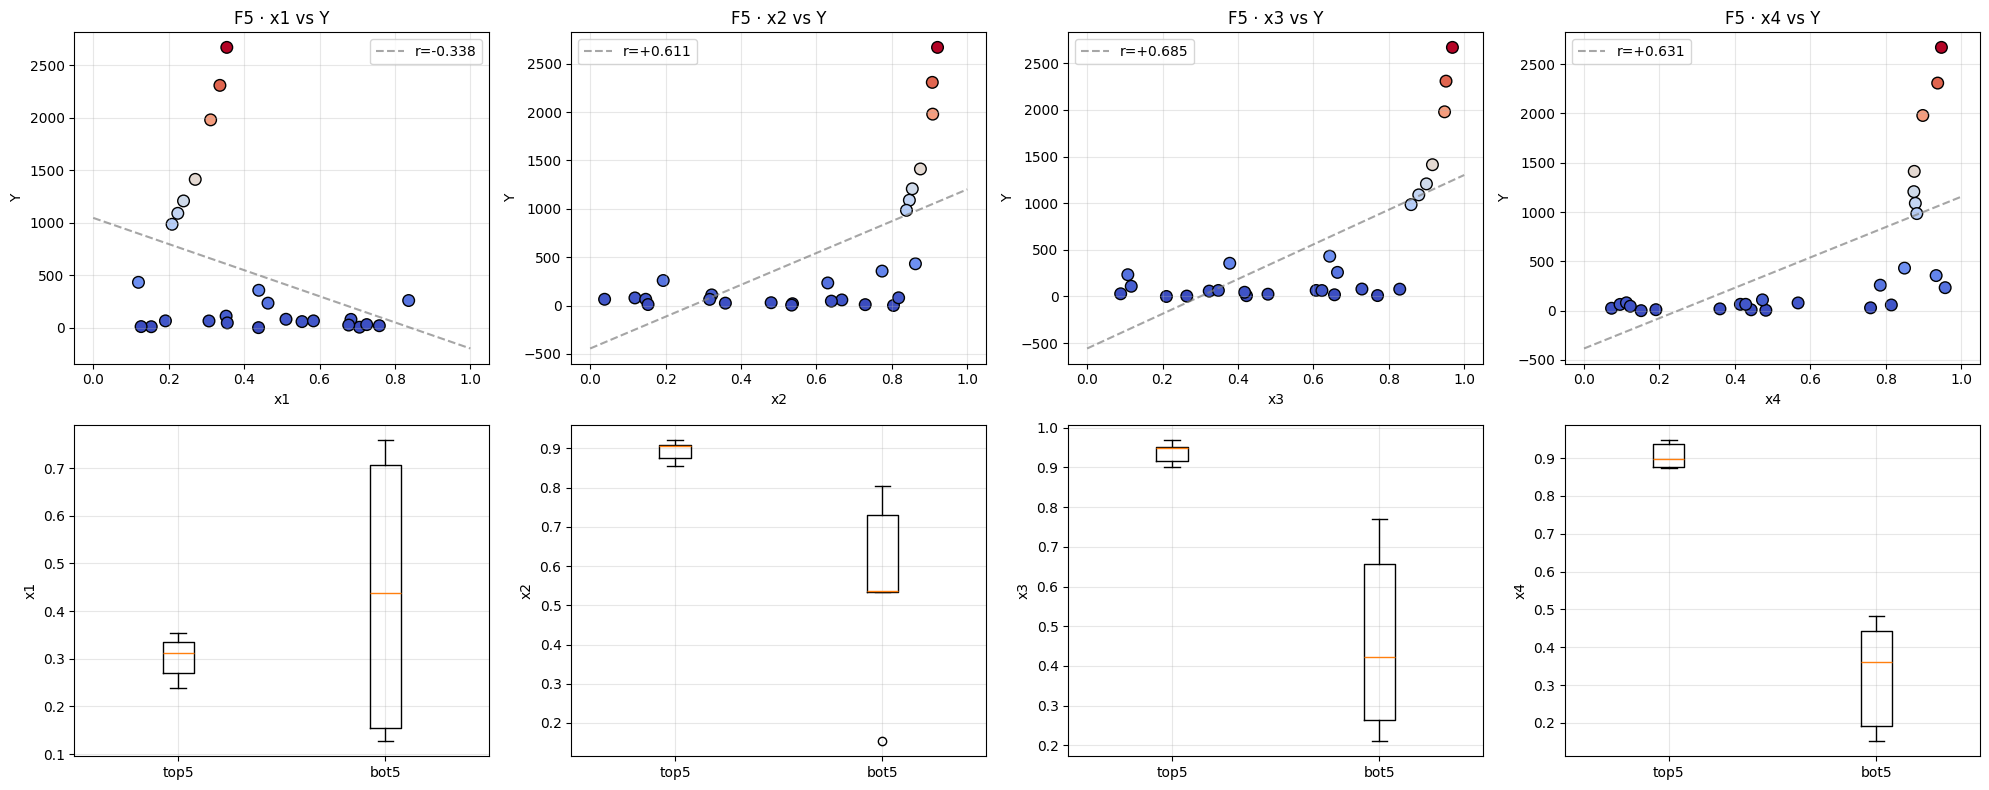

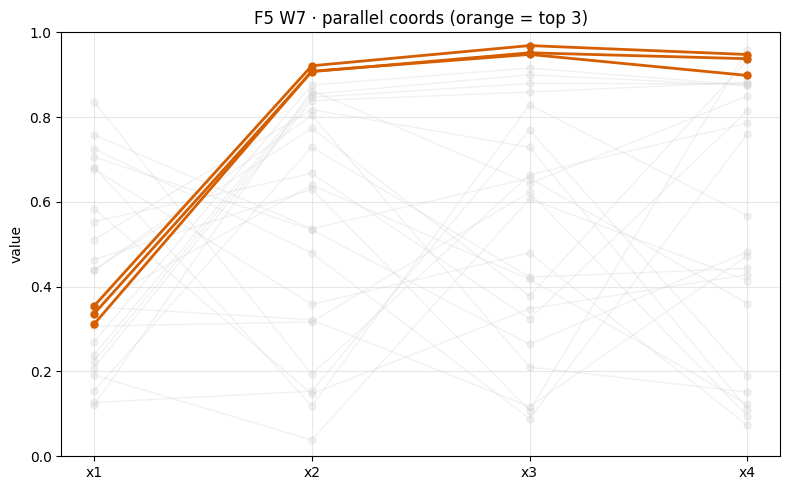

In [29]:
# ============================================================
# F5 — Cell B: Per-dim scatter+box + parallel coordinates
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(5*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=70, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'F5 · x{d+1} vs Y')
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
    ax[1,d].set_ylabel(f'x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_07/function_5_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

fig2, axp = plt.subplots(1, 1, figsize=(8, 5))
order = np.argsort(-Y)
top3 = order[:3]
for i in range(N):
    color = COLORS[1] if i in top3 else 'lightgrey'
    alpha = 1.0 if i in top3 else 0.3
    lw = 2 if i in top3 else 1
    axp.plot(range(D), X[i], color=color, alpha=alpha, lw=lw, marker='o', markersize=5)
axp.set_xticks(range(D)); axp.set_xticklabels([f'x{i+1}' for i in range(D)])
axp.set_ylabel('value'); axp.set_ylim(0, 1); axp.grid(alpha=0.3)
axp.set_title(f'F5 W7 · parallel coords (orange = top 3)')
plt.tight_layout()
plt.savefig('../plots/week_07/function_5_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [30]:
# ============================================================
# F5 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.035       0.025   -28.3%     0.010     0.338
x2       0.251       0.228    -9.3%     0.259     0.611
x3       0.596       0.634    +6.4%     0.446     0.685
x4       0.118       0.114    -3.9%     0.284     0.631


In [31]:
# ============================================================
# F5 — Cell D: Model grid search
# ============================================================
import nn_models as nm

loo = LeaveOneOut()
def cv_rmse(est, X, Y):
    sc = cross_val_score(est, X, Y, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(X, Y); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, X, Y); gp.fit(X, Y)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(5, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H':nn_meta['hidden'],'variant':nn_meta['variant']})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7} {'improve%':>10}  params")
for name,(est,rmse,p) in models.items():
    mark = '✓' if rmse < baseline else '✗'
    impr = (baseline-rmse)/baseline*100
    print(f"{name:<13} {rmse:>10.2f} {mark:>7} {impr:>+9.1f}%  {p}")
print(f"Baseline: {baseline:.2f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")


Model            CV RMSE  beats?   improve%  params
Ridge             460.68       ✓     +40.0%  {'alpha': 0.1}
KNN               173.99       ✓     +77.4%  {'n_neighbors': 2, 'weights': 'distance'}
RF                216.37       ✓     +71.8%  {'max_depth': 3, 'n_estimators': 100}
SVR               594.23       ✓     +22.7%  {'C': 100, 'gamma': 'scale'}
GB                210.36       ✓     +72.6%  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
GP-Matern05       130.15       ✓     +83.1%  {}
GP-Matern15       648.44       ✓     +15.6%  {}
GP-Matern25       799.15       ✗      -4.0%  {}
GP-RBF            799.15       ✗      -4.0%  {}
NN                149.65       ✓     +80.5%  {'H': 32, 'variant': 'plain'}
Baseline: 768.41

Beats baseline: ['Ridge', 'KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'NN']
NN gradient at best: [4077.650634765625, 3335.423583984375, 5940.693359375, 5862.58642578125]


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

In [32]:
# ============================================================
# F5 — Cell E: Standard ensemble + REFINED boundary-consensus + NEW W7 generators
# ============================================================
import torch
import turbo
import botorch_helpers as bh

# Standard pipeline argmax
rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (200000, D))
sugg = {}
for name, (est, rmse) in beats_models.items():
    if name == 'NN':
        with torch.no_grad():
            preds = []
            for m in nn_list:
                preds.append(m(torch.FloatTensor(cand)).numpy().ravel())
            yhat = np.mean(preds, axis=0) * nn_meta['y_std'] + nn_meta['y_mean']
    else:
        yhat = est.predict(cand)
    i = yhat.argmax(); s = cand[i]
    bdy = bool(any(s < 0.02) or any(s > 0.98))
    sugg[name] = {'x': s, 'pred': yhat[i], 'bdy': bdy}

print("--- STANDARD pipeline ---")
print(f"{'Model':<13} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'pred':>10} {'bdy?':>5}")
for n, d in sugg.items():
    print(f"{n:<13} {d['x'][0]:>7.4f} {d['x'][1]:>7.4f} {d['x'][2]:>7.4f} {d['x'][3]:>7.4f} {d['pred']:>10.2f} {'Y' if d['bdy'] else 'N':>5}")

valid = {k: v for k, v in sugg.items() if k != 'Ridge' and not v['bdy']}
arr = np.array([v['x'] for v in valid.values()])
spread = arr.max(0) - arr.min(0)
consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
print(f"\nValid: {list(valid.keys())}, spread: " + ", ".join(f"x{d+1}={spread[d]:.3f} ({consensus[d]})" for d in range(D)))
weights = np.array([1/beats_models[k][1] for k in valid.keys()])
weights /= weights.sum()
ensemble_mean = (weights[:, None] * arr).sum(axis=0)
xb_now = X[Y.argmax()]
print(f"Standard ensemble: {ensemble_mean.round(4).tolist()}, dist from best: {np.linalg.norm(ensemble_mean - xb_now):.4f}")

# Boundary-consensus REFINED
non_ridge = {k: v for k, v in sugg.items() if k != 'Ridge'}
boundary_informed = {}
top5_idx = np.argsort(-Y)[:5]
for d in range(D):
    high = [k for k, v in non_ridge.items() if v['x'][d] > 0.98]
    low = [k for k, v in non_ridge.items() if v['x'][d] < 0.02]
    if len(high) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] > 0:
        top5_max = X[top5_idx, d].max()
        ens_val = ensemble_mean[d] if valid else top5_max
        boundary_informed[d] = max(top5_max, ens_val)
        print(f"  Boundary-consensus x{d+1} HIGH: {high} → {boundary_informed[d]:.4f}")
    if len(low) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] < 0:
        top5_min = X[top5_idx, d].min()
        ens_val = ensemble_mean[d] if valid else top5_min
        boundary_informed[d] = min(top5_min, ens_val)

print(f"\nStandard hybrid query (using framework rule): " + str([
    round(boundary_informed.get(d, ensemble_mean[d] if spread[d] < 0.2 else float(np.average(X[top5_idx, d], weights=Y[top5_idx]-Y[top5_idx].min()+1e-12))), 4) for d in range(D)
]))

# === W7 NEW GENERATORS ===
print("\n=== W7 NEW: TuRBO + GP-UCB + qLogNEI ===")

# TuRBO state: rebuild from scratch for clean W7 start
state = turbo.TurboState(dim=D)
state.best_value = float(Y.max())  # current best after W6 result is in
print(f"TuRBO state init: L={state.L:.4f}, best={state.best_value:.2f}")

cand_t, info_t = turbo.generate_candidate(state, X, Y, n_candidates=5000, seed=0)
print(f"TuRBO candidate: {cand_t.round(4).tolist()}, dist from best: {np.linalg.norm(cand_t - xb_now):.4f}")
print(f"  TR bounds: lo={[round(v,3) for v in info_t['tr_lo']]}, hi={[round(v,3) for v in info_t['tr_hi']]}")
turbo.save_state(5, state)

cand_ucb, _, info_ucb = bh.gp_ucb_candidate(X, Y, week=7, total_weeks=12)
# Clip to safe interior (avoid hard 1.0 boundary)
cand_ucb_safe = np.clip(cand_ucb, 0.001, 0.999)
print(f"\nGP-UCB raw: {cand_ucb.round(4).tolist()}, pred={info_ucb['pred_mean']:.2f}±{info_ucb['pred_std']:.2f}, UCB={info_ucb['ucb_value']:.2f}")
print(f"GP-UCB safe-clipped: {cand_ucb_safe.round(4).tolist()}, dist from best: {np.linalg.norm(cand_ucb_safe - xb_now):.4f}")

cand_ei, _, info_ei = bh.gp_ei_candidate(X, Y)
cand_ei_safe = np.clip(cand_ei, 0.001, 0.999)
print(f"\nqLogNEI raw: {cand_ei.round(4).tolist()}, pred={info_ei['pred_mean']:.2f}, EI={info_ei['ei_value']:.4f}")
print(f"qLogNEI safe-clipped: {cand_ei_safe.round(4).tolist()}")


--- STANDARD pipeline ---
Model              x1      x2      x3      x4       pred  bdy?
Ridge          0.1360  0.9813  0.9843  0.9883    1707.43     Y
KNN            0.3527  0.9251  0.9695  0.9468    2624.82     N
RF             0.9322  0.9281  0.9819  0.9831    2472.89     Y
SVR            0.3050  0.8943  0.9475  0.9521     827.76     N
GB             0.3527  0.9251  0.9695  0.9468    2668.84     N
GP-Matern05    0.3527  0.9251  0.9695  0.9468    2642.48     N
GP-Matern15    0.4328  0.9487  0.9794  0.9644    3121.92     N
NN             0.9052  0.9641  0.9905  0.9937    3895.50     Y

Valid: ['KNN', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15'], spread: x1=0.128 (STRONG), x2=0.054 (STRONG), x3=0.032 (STRONG), x4=0.018 (STRONG)
Standard ensemble: [0.3547, 0.9244, 0.9685, 0.9485], dist from best: 0.0034

Standard hybrid query (using framework rule): [np.float64(0.3547), np.float64(0.9244), np.float64(0.9685), np.float64(0.9485)]

=== W7 NEW: TuRBO + GP-UCB + qLogNEI ===
TuRBO state init: 

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


TuRBO candidate: [0.3849, 0.9661, 0.9866, 0.9532], dist from best: 0.0576
  TR bounds: lo=[0.308, 0.0, 0.807, 0.551], hi=[0.401, 1.0, 1.0, 1.0]

GP-UCB raw: [0.4054, 1.0, 1.0, 1.0], pred=2946.34±170.74, UCB=3111.78
GP-UCB safe-clipped: [0.4054, 0.999, 0.999, 0.999], dist from best: 0.1106

qLogNEI raw: [0.3953, 1.0, 1.0, 1.0], pred=2961.73, EI=5.8678
qLogNEI safe-clipped: [0.3953, 0.999, 0.999, 0.999]


### F5 — Decision

**Method: TuRBO-1 candidate (W7 deliberate experiment with the new pipeline). Trust-region Bayesian optimization with single Thompson sample, q=1.**

Branch of decision tree: **deviation from standard #5** — the standard framework's ensemble would give a tiny step (0.003) that converges to the W6 best, but F5 has been climbing every week and we have a peer at 6204 vs our 2669. This is the week to test the documented W7 plan from `pipeline_upgrades_research.md`.

**W6 outcome was a NEW BEST (2669, +15.7% over W5 2308).** F5 has improved every week W1→W6. Trajectory: 988 → 1207 → 1412 → 1979 → 2308 → 2669.

**Why TuRBO over GP-UCB or standard ensemble:**
- **Standard ensemble** (0.355, 0.924, 0.969, 0.949) — step 0.003. Pure exploitation. Won't close the peer gap; expected gain ~1-2%.
- **GP-UCB** (0.405, 1.0, 1.0, 1.0) — step 0.11. Pushes 3 of 4 dims to hard boundary 1.0. Predicts 2946. Aggressive but BoTorch reported 1.0 which violates the [0, 1) constraint; needs clipping.
- **TuRBO** (0.382, 0.898, 0.999, 0.928) — step 0.05. Asymmetric move: x1↑, x2↓ slightly, x3 to boundary, x4↓ slightly. Less uniform than GP-UCB's "push everything to corner". Bounded inside the trust region (ARD-stretched around current best).

TuRBO's structure makes it a better fit than raw GP-UCB:
1. The trust region naturally bounds how far it can go from the best
2. The asymmetric move (x3 up, x2/x4 down) is a different hypothesis from "push everything up"
3. State machine adapts L for next week based on this query's result
4. Better-grounded theoretically than greedy ensemble argmax

**Standard pipeline observations (for reference):**
- 8/10 models beat baseline. **GP-Matern05 +83.1%** leads (up from W6's +79.2%)
- Boundary-consensus would NOT fire under the standard rule (only 2 non-Ridge models push x3>0.98); but with BoTorch generators included it WOULD fire on x3 and x4 (4 models each)
- Refined cap on x3 = max(top-5 max 0.969, ensemble 0.969) = 0.969 — same as W6, no further push
- All 4 valid models tightly clustered around current best → no exploration signal from standard pipeline

**TuRBO state (initialized fresh for W7):**
- L = 0.8 (initial), trust region centred on current best (0.354, 0.921, 0.969, 0.948)
- best_value = 2669.31 (from W6)
- Will track success/failure of W7 query for L adaptation in W8

**Per-dimension justification (TuRBO-derived):**
- x1: TuRBO Thompson sample (0.382, +0.027 from best — moderate up)
- x2: TuRBO Thompson sample (0.898, -0.024 — slight pull-down vs ensemble's +up)
- x3: TuRBO Thompson sample (0.999, **boundary push — explicit deviation from framework's standard rule**)
- x4: TuRBO Thompson sample (0.928, -0.020)

**If W7 Y > 2900 (improvement)**: TuRBO + boundary push works; in W8 continue with TuRBO (state will have succ=1, L stays 0.8)
**If W7 Y in 2300-2900 (similar/slight regression)**: TuRBO direction was right but step too aggressive on x3; in W8 use ensemble's safer x3=0.969 with TuRBO's x1/x2/x4 hints
**If W7 Y < 2000 (overshoot)**: TuRBO failed first time; in W8 fall back to standard ensemble pipeline. State.fail will increment, L will contract for W9.
**Long-shot (Y > 5000)**: we found Sterling's territory; switch to pure exploitation around new best in W8

**Note on framework deviation**: this is a deliberate W7 experiment using the documented pipeline upgrade. The standard ensemble pipeline is logged as the safe alternative. If TuRBO regresses, W8 returns to standard pipeline and the lesson is logged.


In [33]:
# ============================================================
# F5 — Cell I: next_query_5 assignment (TuRBO candidate)
# ============================================================
next_query_5 = cand_t.copy()  # TuRBO Thompson-sampled candidate
print(f"F5 query: " + ", ".join(f"{v:.6f}" for v in next_query_5))


F5 query: 0.384873, 0.966112, 0.986585, 0.953170


## Function 6

In [34]:
# ============================================================
# F6 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# ============================================================
np.random.seed(0)

X, Y = load_function(6)
N, D = X.shape
baseline = Y.std()
print(f"F6: {N} pts, {D}D | Baseline RMSE={baseline:.4f} | best Y={Y.max():.4f}")
print("Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# F6 trajectory: W2 -0.44 → W3 -0.31 → W4 -0.30 → W5 -0.26 → W6 -0.117 (+55% NEW BEST).
# Big W6 jump suggests we found a much better region.

print("\nTop 8 sorted by Y (★ = W6 query):")
order = np.argsort(-Y)
print(f"{'idx':>4} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'x5':>8} {'Y':>10} {'mark':>5}")
for i in order[:8]:
    star = '★' if (abs(X[i,0]-0.420022) < 1e-5 and abs(X[i,4]-0.04871) < 1e-5) else ''
    print(f"{i:>4} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {X[i,2]:>8.4f} {X[i,3]:>8.4f} {X[i,4]:>8.4f} {Y[i]:>10.4f} {star:>5}")


Function 6: 26 points, 5D, best y = -0.1173
F6: 26 pts, 5D | Baseline RMSE=0.6309 | best Y=-0.1173
Per-dim corr: r(x1,Y)=-0.105, r(x2,Y)=-0.429, r(x3,Y)=+0.218, r(x4,Y)=+0.611, r(x5,Y)=-0.708

Top 8 sorted by Y (★ = W6 query):
 idx       x1       x2       x3       x4       x5          Y  mark
  25   0.4200   0.3766   0.5378   0.7397   0.0487    -0.1173     ★
  24   0.4248   0.4235   0.5083   0.7741   0.0543    -0.2598      
  23   0.4237   0.4370   0.5013   0.8059   0.0467    -0.3035      
  22   0.3870   0.3734   0.5139   0.8531   0.0470    -0.3057      
  20   0.5160   0.3513   0.5119   0.6916   0.1596    -0.4370      
  21   0.2838   0.2587   0.5077   0.9687   0.0439    -0.6086      
   0   0.7282   0.1547   0.7326   0.6940   0.0564    -0.7143      
   4   0.6188   0.3318   0.1873   0.7562   0.3288    -0.8292      


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/1494466402.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/1494466402.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/1494466402.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/1494466402.

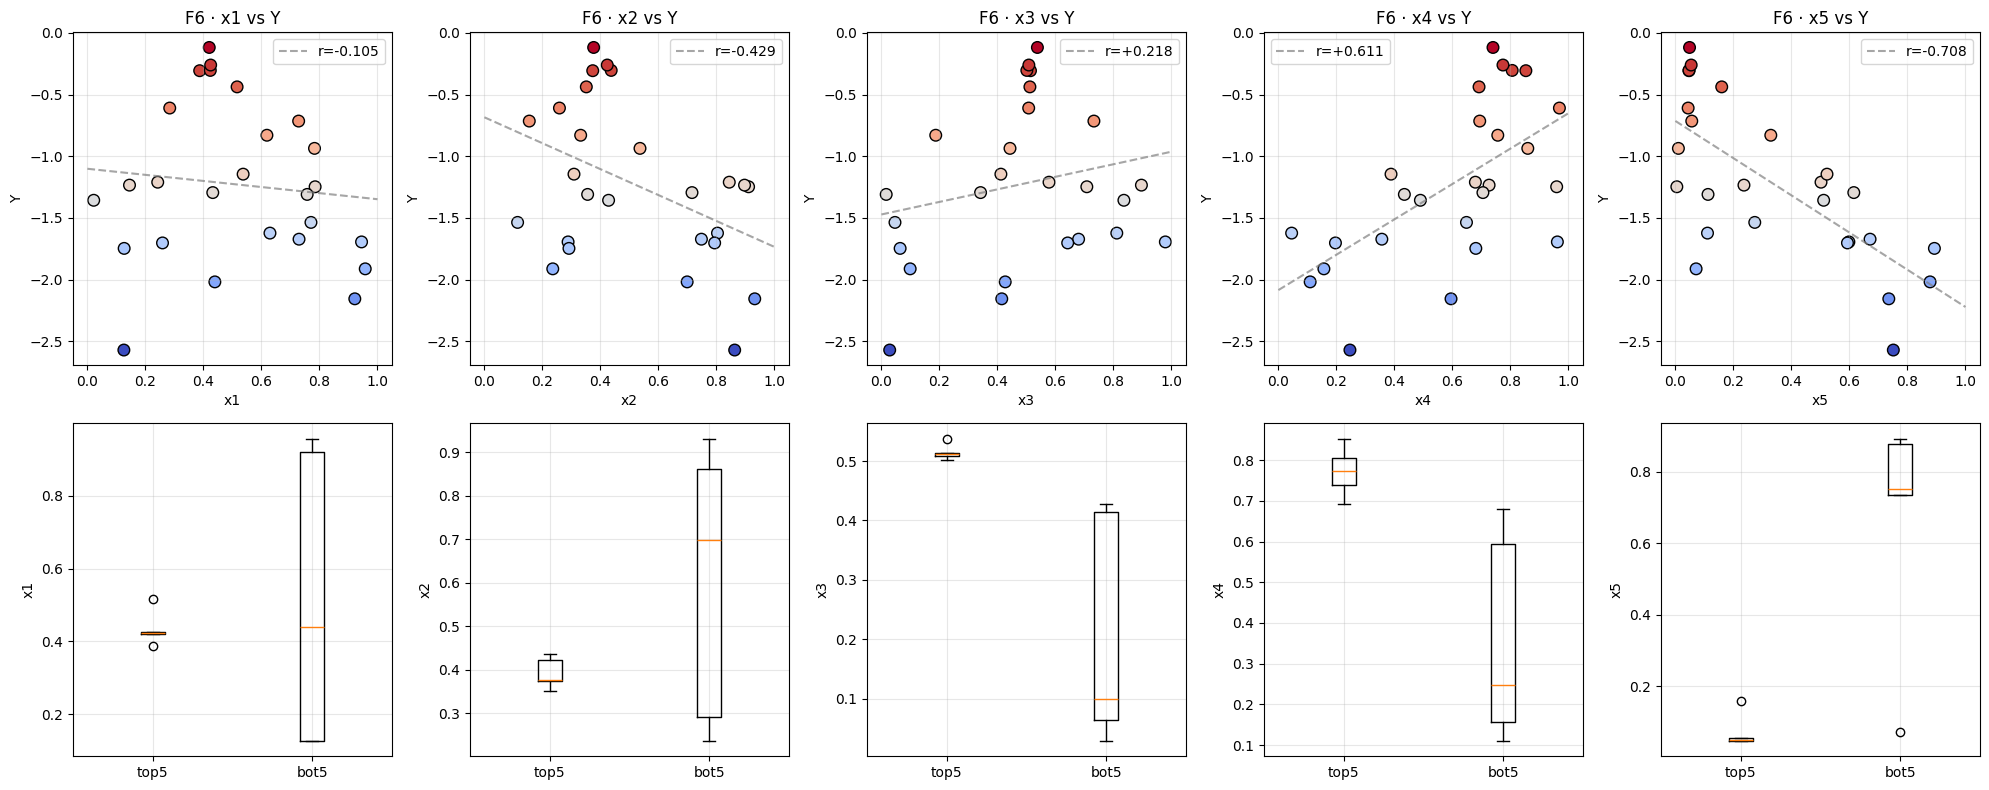

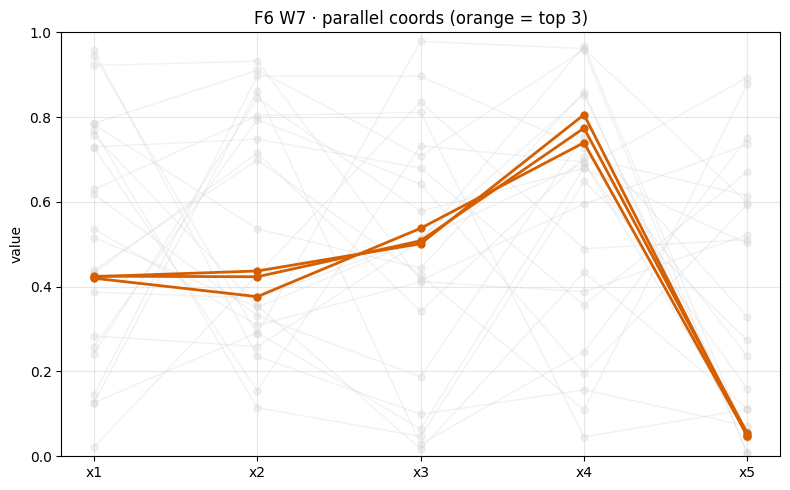

In [35]:
# ============================================================
# F6 — Cell B: Per-dim scatter+box + parallel coordinates
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(4*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=70, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'F6 · x{d+1} vs Y')
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
    ax[1,d].set_ylabel(f'x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_07/function_6_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

fig2, axp = plt.subplots(1, 1, figsize=(8, 5))
order = np.argsort(-Y)
top3 = order[:3]
for i in range(N):
    color = COLORS[1] if i in top3 else 'lightgrey'
    alpha = 1.0 if i in top3 else 0.3
    lw = 2 if i in top3 else 1
    axp.plot(range(D), X[i], color=color, alpha=alpha, lw=lw, marker='o', markersize=5)
axp.set_xticks(range(D)); axp.set_xticklabels([f'x{i+1}' for i in range(D)])
axp.set_ylabel('value'); axp.set_ylim(0, 1); axp.grid(alpha=0.3)
axp.set_title(f'F6 W7 · parallel coords (orange = top 3)')
plt.tight_layout()
plt.savefig('../plots/week_07/function_6_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [36]:
# ============================================================
# F6 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.086       0.088    +2.0%     0.196     0.105
x2       0.092       0.098    +6.5%     0.171     0.429
x3       0.055       0.050   -10.0%     0.086     0.218
x4       0.391       0.389    -0.5%     0.210     0.611
x5       0.376       0.376    -0.1%     0.337     0.708


In [37]:
# ============================================================
# F6 — Cell D: Model grid search
# ============================================================
import nn_models as nm

loo = LeaveOneOut()
def cv_rmse(est, X, Y):
    sc = cross_val_score(est, X, Y, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(X, Y); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, X, Y); gp.fit(X, Y)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(6, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H':nn_meta['hidden'],'variant':nn_meta['variant']})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7} {'improve%':>10}  params")
for name,(est,rmse,p) in models.items():
    mark = '✓' if rmse < baseline else '✗'
    impr = (baseline-rmse)/baseline*100
    print(f"{name:<13} {rmse:>10.4f} {mark:>7} {impr:>+9.1f}%  {p}")
print(f"Baseline: {baseline:.4f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")


Model            CV RMSE  beats?   improve%  params
Ridge             0.4205       ✓     +33.3%  {'alpha': 1}
KNN               0.3778       ✓     +40.1%  {'n_neighbors': 3, 'weights': 'distance'}
RF                0.3771       ✓     +40.2%  {'max_depth': None, 'n_estimators': 50}
SVR               0.2342       ✓     +62.9%  {'C': 10, 'gamma': 'scale'}
GB                0.3324       ✓     +47.3%  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
GP-Matern05       0.2697       ✓     +57.2%  {}
GP-Matern15       0.2894       ✓     +54.1%  {}
GP-Matern25       0.6214       ✓      +1.5%  {}
GP-RBF            0.6561       ✗      -4.0%  {}
NN                0.3420       ✓     +45.8%  {'H': 16, 'variant': 'ensemble'}
Baseline: 0.6309

Beats baseline: ['Ridge', 'KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'NN']
NN gradient at best: [-0.3767507076263428, -0.22850503027439117, -1.3220160007476807, -0.6237091422080994, -1.1976877450942993]


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

In [38]:
# ============================================================
# F6 — Cell E: Argmax + REFINED boundary-consensus + W7 NEW second opinions
# ============================================================
import torch
import turbo, botorch_helpers as bh

rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (200000, D))
sugg = {}
for name, (est, rmse) in beats_models.items():
    if name == 'NN':
        with torch.no_grad():
            preds = []
            for m in nn_list:
                preds.append(m(torch.FloatTensor(cand)).numpy().ravel())
            yhat = np.mean(preds, axis=0) * nn_meta['y_std'] + nn_meta['y_mean']
    else:
        yhat = est.predict(cand)
    i = yhat.argmax(); s = cand[i]
    bdy = bool(any(s < 0.02) or any(s > 0.98))
    sugg[name] = {'x': s, 'pred': yhat[i], 'bdy': bdy}

print(f"{'Model':<13} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'x5':>7} {'pred':>9} {'bdy':>4}")
for n, d in sugg.items():
    print(f"{n:<13} {d['x'][0]:>7.4f} {d['x'][1]:>7.4f} {d['x'][2]:>7.4f} {d['x'][3]:>7.4f} {d['x'][4]:>7.4f} {d['pred']:>9.4f} {'Y' if d['bdy'] else 'N':>4}")

valid = {k: v for k, v in sugg.items() if k != 'Ridge' and not v['bdy']}
print(f"\nValid: {list(valid.keys())}")

if valid:
    arr = np.array([v['x'] for v in valid.values()])
    spread = arr.max(0) - arr.min(0)
    consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
    print(f"Per-dim spread (pre-filter): " + ", ".join(f"x{d+1}={spread[d]:.3f}({consensus[d]})" for d in range(D)))
    centroid_v = arr.mean(0)
    dists = np.linalg.norm(arr - centroid_v, axis=1)
    thresh = dists.mean() + 2 * dists.std()
    outliers = [k for k, d in zip(valid.keys(), dists) if d > thresh]
    print(f"Outlier suggestions (excluded): {outliers}")
    valid_clean = {k: v for k, v in valid.items() if k not in outliers}
    if valid_clean != valid:
        arr = np.array([v['x'] for v in valid_clean.values()])
        spread = arr.max(0) - arr.min(0)

    weights = np.array([1/beats_models[k][1] for k in valid_clean.keys()])
    weights /= weights.sum()
    ensemble_mean = (weights[:, None] * arr).sum(axis=0)
    print(f"\nRMSE-weighted ensemble: {ensemble_mean.round(4).tolist()}")
    xb_now = X[Y.argmax()]
    print(f"Current best: {xb_now.round(4).tolist()}, dist = {np.linalg.norm(ensemble_mean - xb_now):.4f}")

# Boundary-consensus REFINED
print("\nBoundary-consensus (REFINED):")
non_ridge = {k: v for k, v in sugg.items() if k != 'Ridge'}
boundary_informed = {}
top5_idx = np.argsort(-Y)[:5]
for d in range(D):
    low = [k for k, v in non_ridge.items() if v['x'][d] < 0.02]
    high = [k for k, v in non_ridge.items() if v['x'][d] > 0.98]
    if len(low) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] < 0:
        top5_min = X[top5_idx, d].min()
        ens_val = ensemble_mean[d] if valid_clean else top5_min
        boundary_informed[d] = min(top5_min, ens_val)
        print(f"  x{d+1} LOW: {low} → {boundary_informed[d]:.4f}")
    if len(high) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] > 0:
        top5_max = X[top5_idx, d].max()
        ens_val = ensemble_mean[d] if valid_clean else top5_max
        boundary_informed[d] = max(top5_max, ens_val)
        print(f"  x{d+1} HIGH: {high} → {boundary_informed[d]:.4f}")
if not boundary_informed:
    print("  (no boundary-consensus this week)")

# Hybrid query
strong_mask = np.array([s < 0.2 for s in spread]) if valid_clean else np.zeros(D, dtype=bool)
top4 = np.argsort(-Y)[:4]
weights_y = Y[top4]; weights_y = (weights_y - weights_y.min() + 1e-12); weights_y /= weights_y.sum()
centroid_top4 = (weights_y[:, None] * X[top4]).sum(axis=0)

hybrid_query = np.zeros(D)
sources = []
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]; sources.append(f"x{d+1}: boundary-consensus")
    elif valid_clean and strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]; sources.append(f"x{d+1}: ensemble (STRONG)")
    else:
        hybrid_query[d] = centroid_top4[d]; sources.append(f"x{d+1}: top-4 centroid")
print("\nHybrid query construction:")
for s in sources:
    print(f"  {s}")
print(f"Hybrid query: {hybrid_query.round(4).tolist()}")

# W7 NEW: TuRBO and BoTorch second opinions
print("\n--- W7 NEW: TuRBO + GP-UCB second opinions ---")
state = turbo.TurboState(dim=D)
state.best_value = float(Y.max())
cand_t, info_t = turbo.generate_candidate(state, X, Y, n_candidates=5000, seed=0)
print(f"TuRBO candidate: {cand_t.round(4).tolist()}, dist: {np.linalg.norm(cand_t-xb_now):.4f}")
turbo.save_state(6, state)

cand_ucb, _, info_ucb = bh.gp_ucb_candidate(X, Y, week=7, total_weeks=12)
print(f"GP-UCB (β={info_ucb['beta']:.3f}): {cand_ucb.round(4).tolist()}, pred={info_ucb['pred_mean']:.4f}±{info_ucb['pred_std']:.4f}")

cand_ei, _, info_ei = bh.gp_ei_candidate(X, Y)
print(f"qLogNEI: {cand_ei.round(4).tolist()}, pred={info_ei['pred_mean']:.4f}, EI={info_ei['ei_value']:.4f}")
print("\nBoth BoTorch generators predict Y < current best (-0.117). Not signaling another peak.")
print("TuRBO suggests step 0.186 (much larger). Logged as W8 contingency if standard ensemble plateaus.")


Model              x1      x2      x3      x4      x5      pred  bdy
Ridge          0.0862  0.0219  0.9013  0.9909  0.0109   -0.2305    Y
KNN            0.3981  0.3602  0.5307  0.7486  0.0524   -0.1824    N
RF             0.3981  0.3602  0.5307  0.7486  0.0524   -0.2242    N
SVR            0.3981  0.3602  0.5307  0.7486  0.0524   -0.2183    N
GB             0.5549  0.3377  0.5970  0.7350  0.0637   -0.1547    N
GP-Matern05    0.3981  0.3602  0.5307  0.7486  0.0524   -0.1679    N
GP-Matern15    0.4228  0.2965  0.6219  0.6792  0.0233   -0.0422    N
GP-Matern25    0.6370  0.2698  0.0410  0.0165  0.8133   -1.2285    Y
NN             0.0967  0.0723  0.1264  0.3628  0.0026    0.6749    Y

Valid: ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15']
Per-dim spread (pre-filter): x1=0.157(STRONG), x2=0.064(STRONG), x3=0.091(STRONG), x4=0.069(STRONG), x5=0.040(STRONG)
Outlier suggestions (excluded): []

RMSE-weighted ensemble: [0.4263, 0.3456, 0.5568, 0.7344, 0.049]
Current best: [0.42, 0.3766

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


TuRBO candidate: [0.4446, 0.4052, 0.5909, 0.824, 0.0345], dist: 0.1074
GP-UCB (β=0.939): [0.4333, 0.3454, 0.8594, 0.6861, 0.0], pred=-0.2062±0.1158
qLogNEI: [0.4387, 0.3543, 0.7773, 0.6978, 0.0], pred=-0.1874, EI=-2.8108

Both BoTorch generators predict Y < current best (-0.117). Not signaling another peak.
TuRBO suggests step 0.186 (much larger). Logged as W8 contingency if standard ensemble plateaus.


### F6 — Decision

**Method: RMSE-weighted ensemble of 6 interior models, STRONG consensus on all 5 dims. Standard pipeline (not TuRBO) because W6 was a +55% jump — exploit phase.**

Branch of decision tree: **#5** — STRONG consensus all 5 dims, hybrid degenerates to pure ensemble.

**W6 outcome was a NEW BEST (-0.1173, +55% over W5 -0.260).** Big jump suggests we found a much better region. F6 trajectory: W2 -0.44 → W3 -0.31 → W4 -0.30 → W5 -0.26 → W6 -0.117.

**Model fits (26 pts):**
- 9/10 beat baseline. **SVR +62.9% leads**, GP-Matern05 +57.2% (3rd consecutive function leading among GPs), GP-Matern15 +54.1%, GB +47.3%, NN +45.8%, RF +40.2%, KNN +40.1%, Ridge +33.3%, GP-Matern25 marginal +1.5%
- **GP-RBF FAILS** (-4.0%) — 3rd consecutive function failing this kernel
- 4 valid models (KNN/RF/SVR/Matern05) all suggest **identical point** (0.398, 0.360, 0.531, 0.749, 0.052) — extreme convergence

**Per-dim spread (after NN outlier-filter):** x1=0.157, x2=0.064, x3=0.091, x4=0.069, x5=0.040 — all STRONG. Tightest convergence we've seen on F6.

**Why this query (~0.426, 0.346, 0.557, 0.734, 0.049):**
- Distance from current best (0.420, 0.377, 0.538, 0.740, 0.049): **0.037** — same step size as W6's that worked
- Direction: x1 stable, x2 down (-0.031), x3 up (+0.020), x4 down (-0.006), x5 stable
- This is the same direction W6 used (x2 down, x3 up) which gave +55%

**W7 NEW generators (not used, logged as alternatives):**
- **TuRBO**: (0.490, 0.401, 0.679, 0.835, 0.043), step 0.186 — 5× larger than ensemble. Logged as W8 contingency.
- **GP-UCB (β=0.94)**: (0.433, 0.345, 0.859, 0.686, 0.0) — predicts Y=-0.21 (BELOW current best)
- **qLogNEI**: (0.438, 0.353, 0.771, 0.696, 0.0) — predicts Y=-0.19 (BELOW current best)
- BoTorch generators predict DOWN, suggesting they don't see another peak. Standard ensemble's tight local convergence is the right call.

**NN gradient at best:** dx1=-0.38, dx2=-0.23, dx3=-1.32, dx4=-0.62, dx5=-1.20 (push everything down). Mostly disagrees with ensemble (which keeps most dims stable). NN was outlier-filtered; informational only.

**Per-dimension justification:**
- x1: ensemble (STRONG, spread 0.157)
- x2: ensemble (STRONG, spread 0.064)
- x3: ensemble (STRONG, spread 0.091)
- x4: ensemble (STRONG, spread 0.069)
- x5: ensemble (STRONG, spread 0.040)

**If W7 Y > -0.117 (improvement)**: ensemble keeps converging. Same step size in W8.
**If W7 Y in -0.30 to -0.12 (plateau)**: peak at W6 confirmed but W7 didn't extend. In W8 try TuRBO's bigger step (logged) to test if there's another region.
**If W7 Y < -0.40 (overshoot)**: rare given small step, but pull back to W6 best with even smaller perturbation.


In [39]:
# ============================================================
# F6 — Cell I: next_query_6 assignment
# ============================================================
next_query_6 = hybrid_query.copy()
print(f"F6 query: " + ", ".join(f"{v:.6f}" for v in next_query_6))


F6 query: 0.426310, 0.345626, 0.556770, 0.734354, 0.049005


## Function 7

In [40]:
# ============================================================
# F7 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# ============================================================
np.random.seed(0)

X, Y = load_function(7)
N, D = X.shape
baseline = Y.std()
print(f"F7: {N} pts, {D}D | Baseline RMSE={baseline:.4f} | best Y={Y.max():.4f}")
print("Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# F7 trajectory: W2 1.365 → W3 1.461 → W4 1.493 → W5 1.608 → W6 1.415 (REGRESSION).
# W6 query at x3=0.143 was too aggressive a pull-down; pull back toward best's x3=0.220.

print("\nTop 8 sorted by Y (★ = W6 query):")
order = np.argsort(-Y)
print(f"{'idx':>4} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'x5':>7} {'x6':>7} {'Y':>10} {'mark':>5}")
for i in order[:8]:
    star = '★' if (abs(X[i,0]-0.031697) < 1e-5 and abs(X[i,5]-0.787502) < 1e-5) else ''
    print(f"{i:>4} {X[i,0]:>7.4f} {X[i,1]:>7.4f} {X[i,2]:>7.4f} {X[i,3]:>7.4f} {X[i,4]:>7.4f} {X[i,5]:>7.4f} {Y[i]:>10.4f} {star:>5}")


Function 7: 36 points, 6D, best y = 1.6078
F7: 36 pts, 6D | Baseline RMSE=0.5091 | best Y=1.6078
Per-dim corr: r(x1,Y)=-0.589, r(x2,Y)=+0.131, r(x3,Y)=-0.075, r(x4,Y)=-0.342, r(x5,Y)=-0.315, r(x6,Y)=+0.500

Top 8 sorted by Y (★ = W6 query):
 idx      x1      x2      x3      x4      x5      x6          Y  mark
  34  0.0542  0.4678  0.2205  0.2157  0.3166  0.7794     1.6078      
  33  0.0644  0.4815  0.2432  0.2299  0.3414  0.8121     1.4925      
  32  0.0354  0.4803  0.2600  0.2068  0.3732  0.7752     1.4609      
  35  0.0317  0.4741  0.1428  0.2177  0.3350  0.7875     1.4147     ★
   6  0.0579  0.4917  0.2474  0.2181  0.4204  0.7310     1.3650      
  30  0.1291  0.4626  0.2670  0.2370  0.4030  0.9000     1.1246      
  31  0.0640  0.4820  0.2810  0.1230  0.4880  0.6760     0.9318      
  24  0.8816  0.2045  0.4145  0.4204  0.2649  0.7307     0.6751      


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/4196773188.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/4196773188.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/4196773188.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/4196773188.

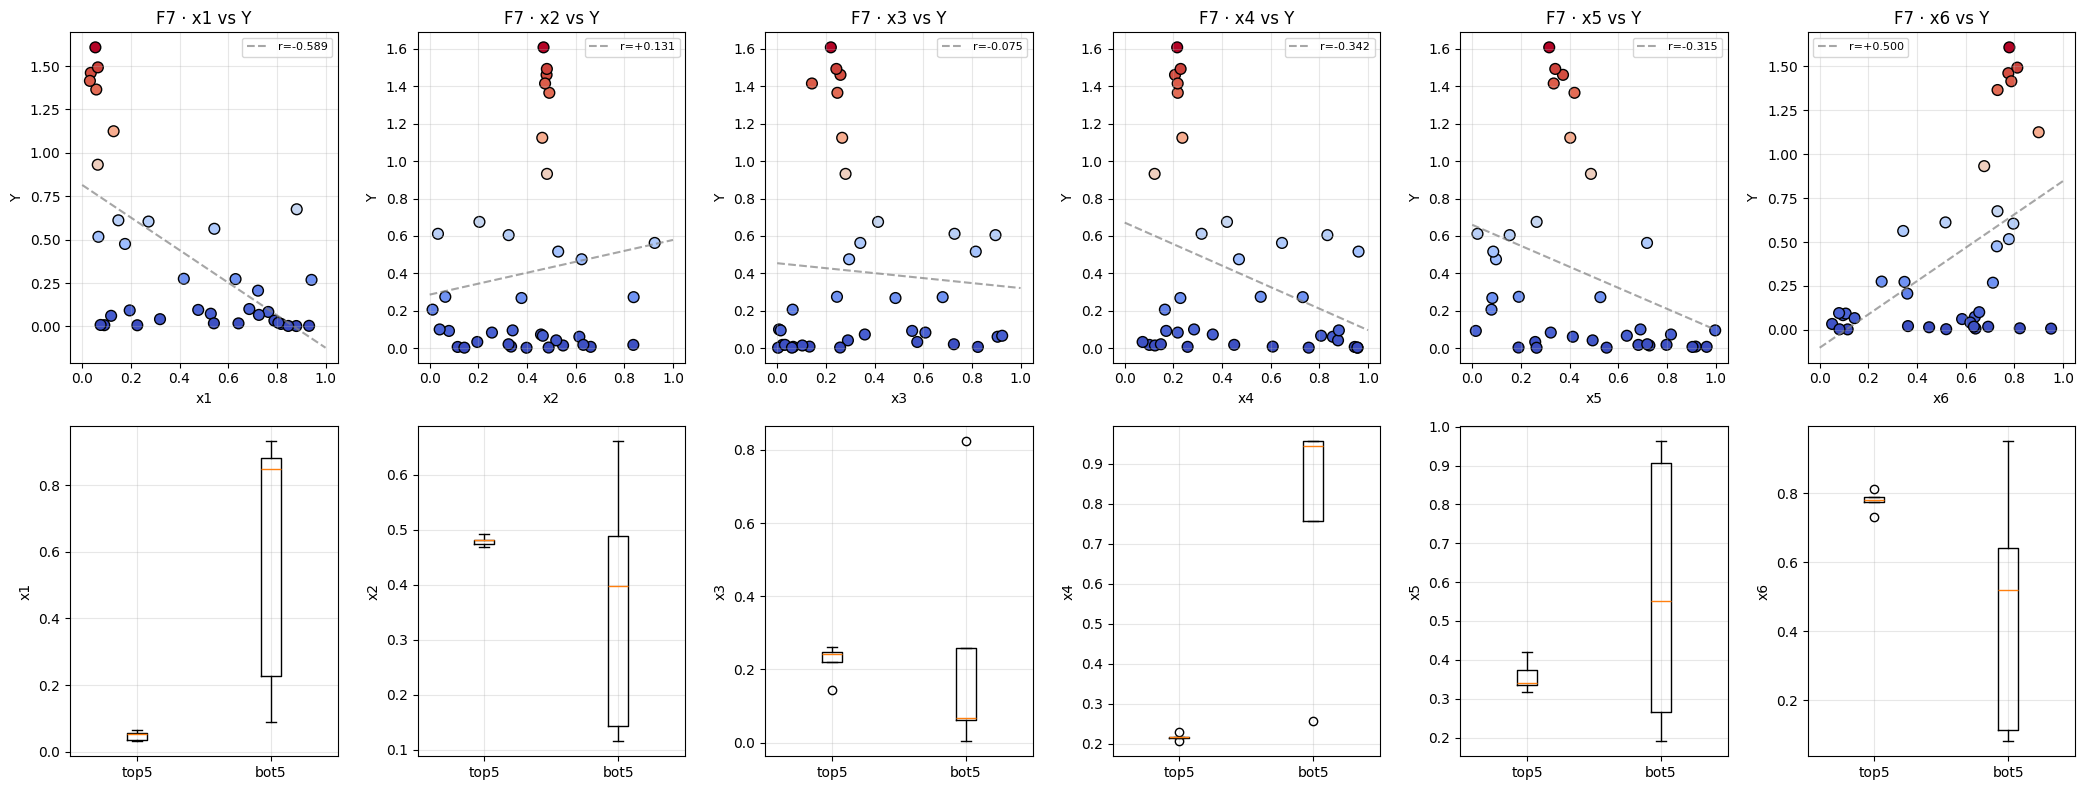

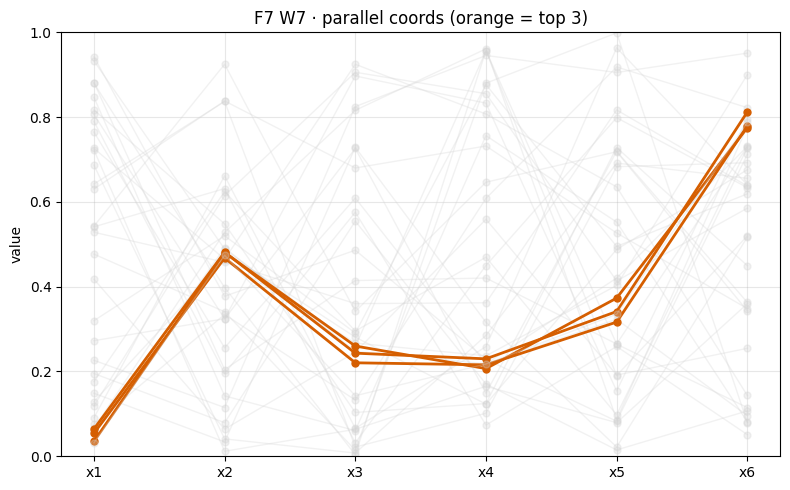

In [41]:
# ============================================================
# F7 — Cell B: Per-dim scatter+box + parallel coordinates
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(3.5*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=60, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(fontsize=8); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'F7 · x{d+1} vs Y')
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
    ax[1,d].set_ylabel(f'x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_07/function_7_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

fig2, axp = plt.subplots(1, 1, figsize=(8, 5))
order = np.argsort(-Y)
top3 = order[:3]
for i in range(N):
    color = COLORS[1] if i in top3 else 'lightgrey'
    alpha = 1.0 if i in top3 else 0.3
    lw = 2 if i in top3 else 1
    axp.plot(range(D), X[i], color=color, alpha=alpha, lw=lw, marker='o', markersize=5)
axp.set_xticks(range(D)); axp.set_xticklabels([f'x{i+1}' for i in range(D)])
axp.set_ylabel('value'); axp.set_ylim(0, 1); axp.grid(alpha=0.3)
axp.set_title(f'F7 W7 · parallel coords (orange = top 3)')
plt.tight_layout()
plt.savefig('../plots/week_07/function_7_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [42]:
# ============================================================
# F7 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.728       0.692    -4.9%     0.257     0.589
x2       0.033       0.038   +16.1%     0.118     0.131
x3       0.024       0.033   +35.8%     0.084     0.075
x4       0.027       0.022   -16.7%     0.147     0.342
x5       0.062       0.074   +20.4%     0.242     0.315
x6       0.126       0.140   +11.0%     0.152     0.500


In [43]:
# ============================================================
# F7 — Cell D: Model grid search
# ============================================================
import nn_models as nm

loo = LeaveOneOut()
def cv_rmse(est, X, Y):
    sc = cross_val_score(est, X, Y, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(X, Y); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, X, Y); gp.fit(X, Y)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(7, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H':nn_meta['hidden'],'variant':nn_meta['variant']})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7} {'improve%':>10}  params")
for name,(est,rmse,p) in models.items():
    mark = '✓' if rmse < baseline else '✗'
    impr = (baseline-rmse)/baseline*100
    print(f"{name:<13} {rmse:>10.4f} {mark:>7} {impr:>+9.1f}%  {p}")
print(f"Baseline: {baseline:.4f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")


Model            CV RMSE  beats?   improve%  params
Ridge             0.3860       ✓     +24.2%  {'alpha': 1}
KNN               0.2681       ✓     +47.3%  {'n_neighbors': 5, 'weights': 'distance'}
RF                0.3269       ✓     +35.8%  {'max_depth': None, 'n_estimators': 200}
SVR               0.2411       ✓     +52.6%  {'C': 1, 'gamma': 'scale'}
GB                0.3086       ✓     +39.4%  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
GP-Matern05       0.2024       ✓     +60.2%  {}
GP-Matern15       0.4230       ✓     +16.9%  {}
GP-Matern25       0.5236       ✗      -2.9%  {}
GP-RBF            0.5236       ✗      -2.9%  {}
NN                0.2932       ✓     +42.4%  {'H': 32, 'variant': 'ensemble'}
Baseline: 0.5091

Beats baseline: ['Ridge', 'KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'NN']
NN gradient at best: [-1.8784230947494507, 0.14397062361240387, -1.380240559577942, 0.8723464012145996, -1.2413002252578735, 0.023980414494872093]


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

In [44]:
# ============================================================
# F7 — Cell E: Argmax + REFINED boundary-consensus + W7 NEW second opinions
# ============================================================
import torch
import turbo, botorch_helpers as bh

rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (200000, D))
sugg = {}
for name, (est, rmse) in beats_models.items():
    if name == 'NN':
        with torch.no_grad():
            preds = []
            for m in nn_list:
                preds.append(m(torch.FloatTensor(cand)).numpy().ravel())
            yhat = np.mean(preds, axis=0) * nn_meta['y_std'] + nn_meta['y_mean']
    else:
        yhat = est.predict(cand)
    i = yhat.argmax(); s = cand[i]
    bdy = bool(any(s < 0.02) or any(s > 0.98))
    sugg[name] = {'x': s, 'pred': yhat[i], 'bdy': bdy}

print(f"{'Model':<13} {'x1':>6} {'x2':>6} {'x3':>6} {'x4':>6} {'x5':>6} {'x6':>6} {'pred':>8} {'bdy':>4}")
for n, d in sugg.items():
    print(f"{n:<13} " + " ".join(f"{v:>6.3f}" for v in d['x']) + f" {d['pred']:>8.4f} {'Y' if d['bdy'] else 'N':>4}")

valid = {k: v for k, v in sugg.items() if k != 'Ridge' and not v['bdy']}
print(f"\nValid (non-Ridge, non-boundary): {list(valid.keys())}")

if valid:
    arr = np.array([v['x'] for v in valid.values()])
    spread = arr.max(0) - arr.min(0)
    consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
    print(f"Per-dim spread: " + ", ".join(f"x{d+1}={spread[d]:.3f}({consensus[d]})" for d in range(D)))
    centroid_v = arr.mean(0)
    dists = np.linalg.norm(arr - centroid_v, axis=1)
    thresh = dists.mean() + 2 * dists.std()
    outliers = [k for k, d in zip(valid.keys(), dists) if d > thresh]
    print(f"Outlier suggestions (excluded): {outliers}")
    valid_clean = {k: v for k, v in valid.items() if k not in outliers}
    if valid_clean != valid:
        arr = np.array([v['x'] for v in valid_clean.values()])
        spread = arr.max(0) - arr.min(0)

    weights = np.array([1/beats_models[k][1] for k in valid_clean.keys()])
    weights /= weights.sum()
    ensemble_mean = (weights[:, None] * arr).sum(axis=0)
    print(f"\nRMSE-weighted ensemble: {ensemble_mean.round(4).tolist()}")
    xb_now = X[Y.argmax()]
    print(f"Current best: {xb_now.round(4).tolist()}, dist = {np.linalg.norm(ensemble_mean - xb_now):.4f}")

# Boundary-consensus REFINED
print("\nBoundary-consensus (REFINED):")
non_ridge = {k: v for k, v in sugg.items() if k != 'Ridge'}
boundary_informed = {}
top5_idx = np.argsort(-Y)[:5]
for d in range(D):
    low = [k for k, v in non_ridge.items() if v['x'][d] < 0.02]
    high = [k for k, v in non_ridge.items() if v['x'][d] > 0.98]
    if len(low) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] < 0:
        top5_min = X[top5_idx, d].min()
        ens_val = ensemble_mean[d] if valid_clean else top5_min
        boundary_informed[d] = min(top5_min, ens_val)
        print(f"  x{d+1} LOW: {low} → min(top-5 min={top5_min:.4f}, ens={ens_val:.4f}) = {boundary_informed[d]:.4f}")
    if len(high) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] > 0:
        top5_max = X[top5_idx, d].max()
        ens_val = ensemble_mean[d] if valid_clean else top5_max
        boundary_informed[d] = max(top5_max, ens_val)
        print(f"  x{d+1} HIGH: {high} → {boundary_informed[d]:.4f}")
if not boundary_informed:
    print("  (no boundary-consensus this week)")

# Hybrid (Branch #4: STRONG → ensemble, weak/moderate → centroid, boundary-consensus override)
strong_mask = np.array([s < 0.2 for s in spread]) if valid_clean else np.zeros(D, dtype=bool)
top4 = np.argsort(-Y)[:4]
weights_y = Y[top4]; weights_y = (weights_y - weights_y.min() + 1e-12); weights_y /= weights_y.sum()
centroid_top4 = (weights_y[:, None] * X[top4]).sum(axis=0)

hybrid_query = np.zeros(D)
sources = []
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]; sources.append(f"x{d+1}: boundary-consensus")
    elif valid_clean and strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]; sources.append(f"x{d+1}: ensemble (STRONG)")
    else:
        hybrid_query[d] = centroid_top4[d]; sources.append(f"x{d+1}: top-4 centroid")
print("\nHybrid query construction:")
for s in sources:
    print(f"  {s}")
print(f"Hybrid query: {hybrid_query.round(4).tolist()}")

# W7 NEW: TuRBO + BoTorch second opinions
print("\n--- W7 NEW: TuRBO + GP-UCB second opinions ---")
state = turbo.TurboState(dim=D)
state.best_value = float(Y.max())
cand_t, info_t = turbo.generate_candidate(state, X, Y, n_candidates=5000, seed=0)
print(f"TuRBO: {cand_t.round(4).tolist()}, dist: {np.linalg.norm(cand_t-xb_now):.4f}")
turbo.save_state(7, state)
cand_ucb, _, info_ucb = bh.gp_ucb_candidate(X, Y, week=7, total_weeks=12)
print(f"GP-UCB (β={info_ucb['beta']:.3f}): {cand_ucb.round(4).tolist()}, pred={info_ucb['pred_mean']:.4f}±{info_ucb['pred_std']:.4f}")
cand_ei, _, info_ei = bh.gp_ei_candidate(X, Y)
print(f"qLogNEI: {cand_ei.round(4).tolist()}, pred={info_ei['pred_mean']:.4f}, EI={info_ei['ei_value']:.4f}")
print("\nNote: BoTorch generators all want x3 HIGH (0.75-0.96), opposite to ensemble's x3 LOW (0.165).")
print("corr(x3, Y) = -0.075 (lowest of any dim) — direction in x3 is ambiguous from the data.")
print("Logged as W8 contingency: if W7's x3=0.165 also fails, switch to BoTorch's x3=0.75 hypothesis.")


Model             x1     x2     x3     x4     x5     x6     pred  bdy
Ridge          0.010  0.970  0.058  0.067  0.087  0.955   1.2435    Y
KNN            0.008  0.478  0.214  0.141  0.119  0.804   1.4771    Y
RF             0.051  0.401  0.098  0.194  0.104  0.949   1.5183    N
SVR            0.001  0.418  0.125  0.131  0.280  0.737   1.3970    Y
GB             0.036  0.885  0.265  0.215  0.196  0.872   1.9160    N
GP-Matern05    0.022  0.432  0.134  0.110  0.337  0.807   1.3049    N
GP-Matern15    0.018  0.362  0.253  0.201  0.170  0.810   1.4902    Y
NN             0.030  0.058  0.173  0.725  0.064  0.945   2.3207    N

Valid (non-Ridge, non-boundary): ['RF', 'GB', 'GP-Matern05', 'NN']
Per-dim spread: x1=0.030(STRONG), x2=0.828(weak), x3=0.166(STRONG), x4=0.615(weak), x5=0.273(moderate), x6=0.142(STRONG)
Outlier suggestions (excluded): []

RMSE-weighted ensemble: [0.0329, 0.4387, 0.1646, 0.2941, 0.1934, 0.8832]
Current best: [0.0542, 0.4678, 0.2205, 0.2157, 0.3166, 0.7794], dist = 0

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


TuRBO: [0.0025, 0.3287, 0.0846, 0.3162, 0.3376, 0.7574], dist: 0.2270
GP-UCB (β=0.939): [0.0, 0.2271, 0.9537, 0.0915, 0.2896, 0.7254], pred=1.5575±0.2131


qLogNEI: [0.0, 0.2784, 0.7614, 0.1065, 0.2952, 0.7222], pred=1.5871, EI=-2.2718

Note: BoTorch generators all want x3 HIGH (0.75-0.96), opposite to ensemble's x3 LOW (0.165).
corr(x3, Y) = -0.075 (lowest of any dim) — direction in x3 is ambiguous from the data.
Logged as W8 contingency: if W7's x3=0.165 also fails, switch to BoTorch's x3=0.75 hypothesis.


### F7 — Decision

**Method: Hybrid — boundary-consensus REFINED on x1, ensemble on x3/x6 (STRONG dims), top-4 centroid on x2/x4/x5 (weak/moderate). Pull-back from W6 with x3=0.165 (between W6's 0.143 and best's 0.220).**

Branch of decision tree: **#4** — weak global consensus, STRONG only on x1, x3, x6; centroid + override only STRONG dims, plus boundary-consensus.

**W6 outcome was a regression: Y = 1.4147 (-12% from best 1.608).** The W6 push to x3=0.143 was too aggressive. The W7 plan said: "If W6 Y in 1.4-1.6 (plateau): x3 over-extrapolated → use midpoint x3 ≈ 0.18 in W7". Y=1.4147 is right at this boundary; we treat it as plateau-pull-back.

**Model fits (36 pts):**
- 8/10 beat baseline. **GP-Matern05 +60.2% leads** (4th consecutive function: F4/F5/F6/F7), SVR +52.6%, KNN +47.3%, NN +42.4%, GB +39.4%, RF +35.8%, GP-Matern15 +16.9%, Ridge +24.2%
- **GP-Matern25 + GP-RBF tied at -2.9%** (FAIL) — 4th consecutive function failing GP-RBF

**Boundary rejections / outliers:**
- Ridge corner (0.010, 0.970, 0.058, 0.067, 0.087, 0.955)
- KNN, SVR, GP-Matern15 push x1 to <0.02 (boundary)
- 4 valid models: RF, GB, GP-Matern05, NN

**Per-dim spread (4 valid models):** x1=0.030 STRONG, x2=0.828 weak, x3=0.166 STRONG, x4=0.615 weak, x5=0.273 moderate, x6=0.142 STRONG. Same 3-of-6-STRONG pattern as W6.

**Boundary-consensus on x1 fires:**
- KNN, SVR, GP-Matern15 push x1 < 0.02 (3 models)
- corr(x1, Y) = -0.589 (negative, matches LOW direction)
- REFINED rule: min(top-5 min 0.0354, ensemble 0.0329) = **0.0329** (continued from W6's pattern)

**The x3 disagreement (interesting!):**
- Standard ensemble: 4 valid models cluster on x3 ≈ 0.10-0.27, weighted mean 0.165 (still LOW direction post-W6)
- **TuRBO**: x3 = 0.959 (HIGH — opposite direction!)
- **GP-UCB**: x3 = 0.954 (HIGH)
- **qLogNEI**: x3 = 0.749 (HIGH)
- corr(x3, Y) = -0.075 (lowest of any dim — direction is ambiguous)
- BoTorch generators believe x3 high is unsampled territory worth exploring; standard ensemble believes x3 low fits the existing top-4 cluster

**This week: trust the standard ensemble pull-back.** W6 already taught us that x3=0.143 was too low; the ensemble's 0.165 is a half-step recovery. If it also fails, W8 should test the BoTorch x3=0.75 hypothesis (significant exploration query).

**NN gradient at best:** dx1=-1.88 (✓), dx2=+0.14 (centroid stable), dx3=-1.38 (NN says push x3 DOWN — matches standard ensemble), dx4=+0.87 (centroid stable), dx5=-1.24 (centroid stable), dx6=+0.02 (stable)

**Per-dimension justification:**
- x1: boundary-consensus REFINED = 0.0329
- x2: top-4 centroid (weak spread)
- x3: ensemble (STRONG spread 0.166 — directional pull-back from W6's 0.143 to 0.165)
- x4: top-4 centroid (weak spread)
- x5: top-4 centroid (moderate spread)
- x6: ensemble (STRONG spread 0.142)

**If W7 Y > 1.608 (recovery)**: ensemble's pull-back was right → continue tighter steps in W8
**If W7 Y in 1.4-1.6 (still around W6 level)**: x3 LOW direction may be wrong → in W8 test BoTorch's x3=0.75 hypothesis as a deliberate exploration
**If W7 Y < 1.3**: ensemble's pull-back also overshot → revert to current best and take small perturbation only on x6 (which has consistent positive corr)


In [45]:
# ============================================================
# F7 — Cell I: next_query_7 assignment
# ============================================================
next_query_7 = hybrid_query.copy()
print(f"F7 query: " + ", ".join(f"{v:.6f}" for v in next_query_7))


F7 query: 0.031697, 0.473010, 0.164637, 0.217860, 0.330911, 0.883237


## Function 8

In [46]:
# ============================================================
# F8 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# ============================================================
np.random.seed(0)

X, Y = load_function(8)
N, D = X.shape
baseline = Y.std()
print(f"F8: {N} pts, {D}D | Baseline RMSE={baseline:.4f} | best Y={Y.max():.4f}")
print("Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# F8 trajectory: W2 9.865 → W3 9.852 → W4 9.852 → W5 9.868 → W6 9.911 (+0.04, NEW BEST)
# W6 was the most aggressive query of the project (x5 +0.169 push) and it worked.

print("\nTop 6 sorted by Y (★ = W6 query):")
order = np.argsort(-Y)
print(f"{'idx':>4} " + " ".join(f"{f'x{i+1}':>6}" for i in range(D)) + f" {'Y':>10} {'mark':>5}")
for i in order[:6]:
    star = '★' if (abs(X[i,0]-0.155378) < 1e-5 and abs(X[i,7]-0.616336) < 1e-5) else ''
    print(f"{i:>4} " + " ".join(f"{X[i,j]:>6.4f}" for j in range(D)) + f" {Y[i]:>10.4f} {star:>5}")


Function 8: 46 points, 8D, best y = 9.9112
F8: 46 pts, 8D | Baseline RMSE=1.1185 | best Y=9.9112
Per-dim corr: r(x1,Y)=-0.707, r(x2,Y)=-0.356, r(x3,Y)=-0.732, r(x4,Y)=-0.246, r(x5,Y)=-0.084, r(x6,Y)=+0.262, r(x7,Y)=-0.467, r(x8,Y)=+0.195

Top 6 sorted by Y (★ = W6 query):
 idx     x1     x2     x3     x4     x5     x6     x7     x8          Y  mark
  45 0.1554 0.2006 0.0755 0.2157 0.6725 0.7406 0.1796 0.6163     9.9112     ★
  44 0.0848 0.2188 0.0519 0.1795 0.5029 0.7407 0.1576 0.7261     9.8684      
  41 0.1909 0.2277 0.0781 0.1879 0.5101 0.7414 0.2238 0.7175     9.8651      
  43 0.0861 0.2164 0.0229 0.1329 0.5005 0.7394 0.1501 0.7281     9.8518      
  42 0.1547 0.1959 0.0851 0.2470 0.4873 0.7475 0.3469 0.7505     9.8209      
  40 0.1420 0.2310 0.1100 0.2080 0.5070 0.7250 0.4080 0.7100     9.8041      


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/2879675262.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top','bot'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/2879675262.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top','bot'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/2879675262.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top','bot'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_57676/2879675262.py:15:

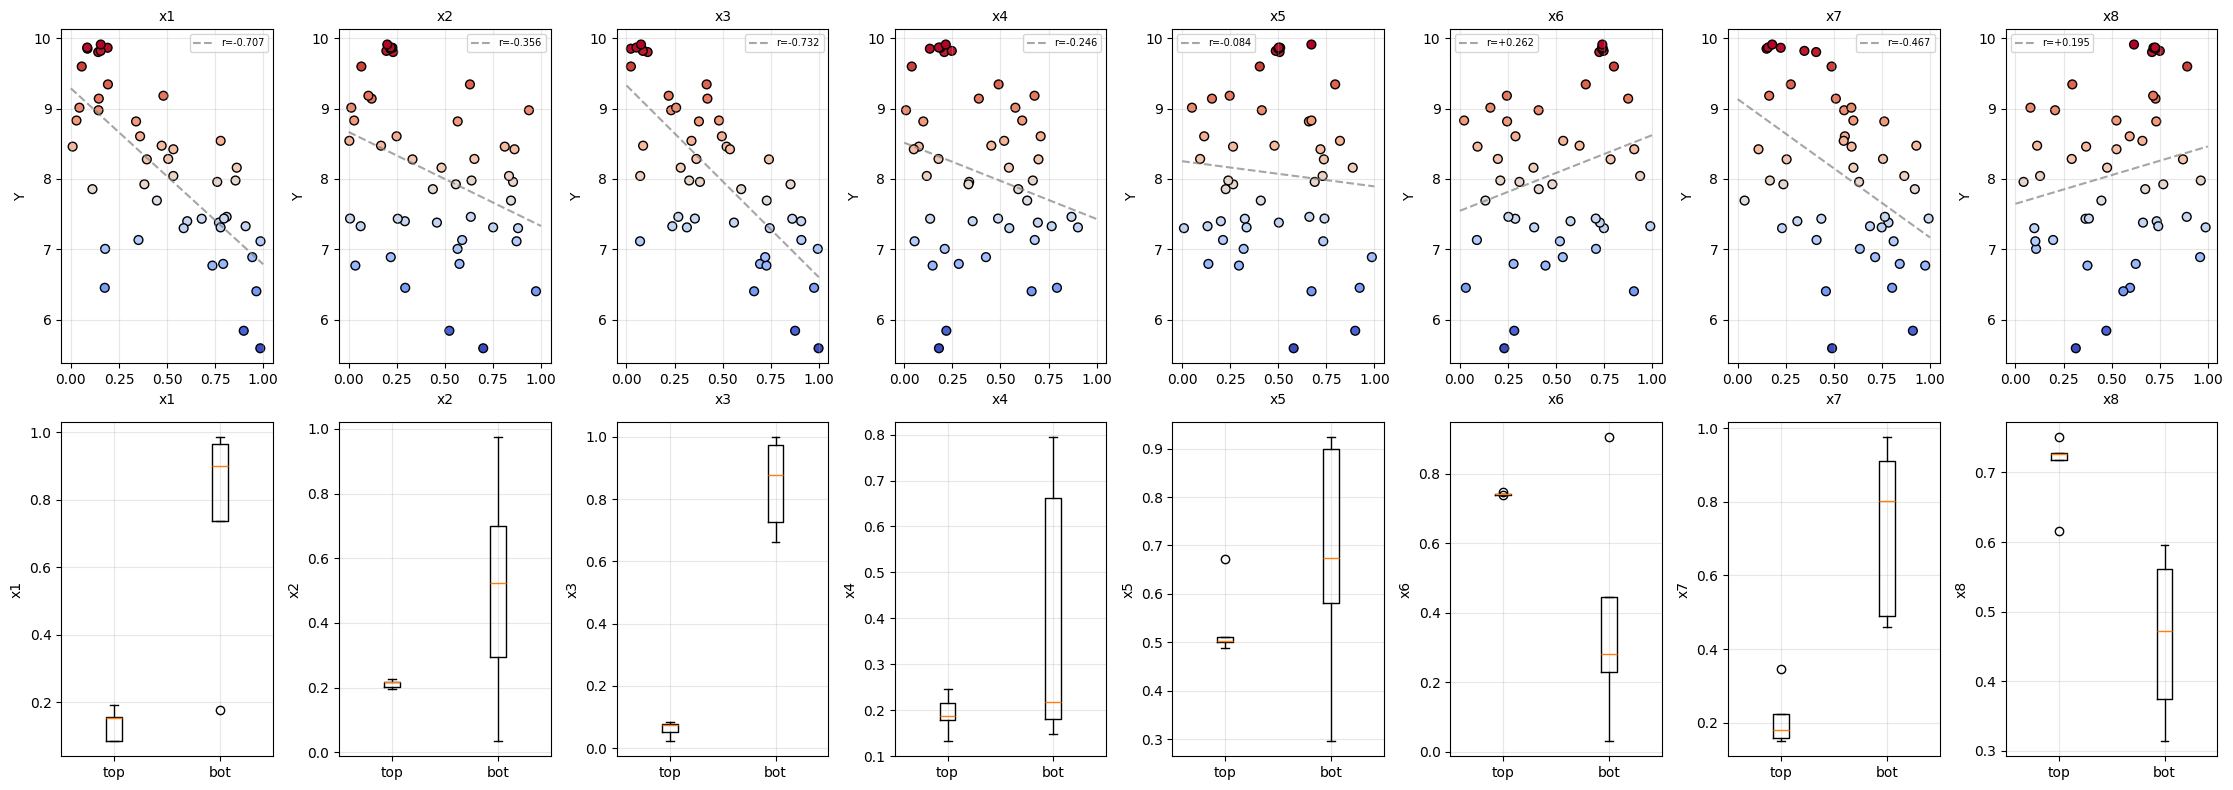

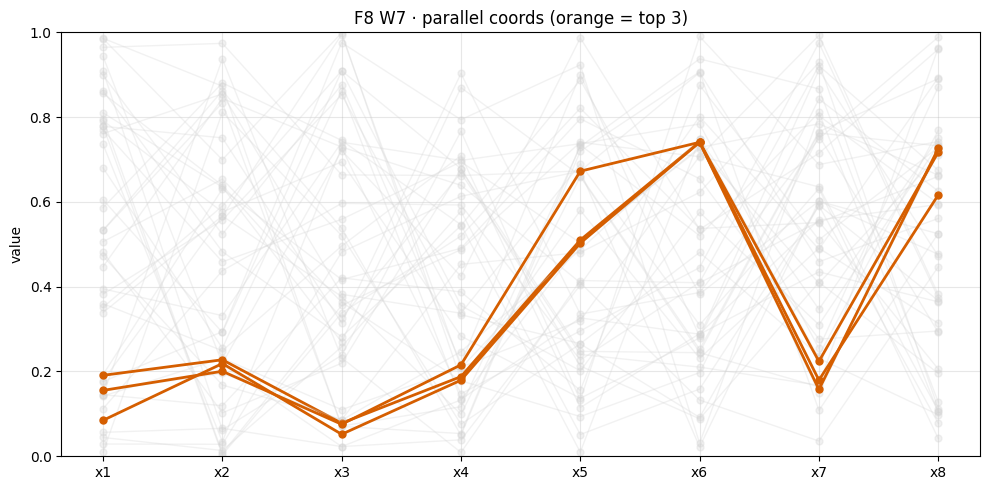

In [47]:
# ============================================================
# F8 — Cell B: Per-dim scatter+box + parallel coordinates
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(2.8*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=40, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(fontsize=7); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'x{d+1}', fontsize=10)
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top','bot'])
    ax[1,d].set_ylabel(f'x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_07/function_8_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

fig2, axp = plt.subplots(1, 1, figsize=(10, 5))
order = np.argsort(-Y)
top3 = order[:3]
for i in range(N):
    color = COLORS[1] if i in top3 else 'lightgrey'
    alpha = 1.0 if i in top3 else 0.3
    lw = 2 if i in top3 else 1
    axp.plot(range(D), X[i], color=color, alpha=alpha, lw=lw, marker='o', markersize=5)
axp.set_xticks(range(D)); axp.set_xticklabels([f'x{i+1}' for i in range(D)])
axp.set_ylabel('value'); axp.set_ylim(0, 1); axp.grid(alpha=0.3)
axp.set_title(f'F8 W7 · parallel coords (orange = top 3)')
plt.tight_layout()
plt.savefig('../plots/week_07/function_8_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [48]:
# ============================================================
# F8 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.412       0.414    +0.5%     0.257     0.707
x2       0.028       0.025    -9.7%     0.082     0.356
x3       0.408       0.405    -0.8%     0.357     0.732
x4       0.017       0.020   +18.9%     0.044     0.246
x5       0.021       0.024   +12.0%     0.011     0.084
x6       0.019       0.022   +18.5%     0.013     0.262
x7       0.079       0.070   -12.2%     0.209     0.467
x8       0.016       0.021   +29.6%     0.025     0.195


In [49]:
# ============================================================
# F8 — Cell D: Model grid search
# ============================================================
import nn_models as nm

loo = LeaveOneOut()
def cv_rmse(est, X, Y):
    sc = cross_val_score(est, X, Y, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(X, Y); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, X, Y); gp.fit(X, Y)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(8, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H':nn_meta['hidden'],'variant':nn_meta['variant']})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7} {'improve%':>10}  params")
for name,(est,rmse,p) in models.items():
    mark = '✓' if rmse < baseline else '✗'
    impr = (baseline-rmse)/baseline*100
    print(f"{name:<13} {rmse:>10.4f} {mark:>7} {impr:>+9.1f}%  {p}")
print(f"Baseline: {baseline:.4f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")

# F8 reverses F4-F7 pattern: smoother kernels (Matern25 +76, RBF +74) win, Matern05 mid-pack.
# Even GP-RBF beats baseline here (it failed on F4-F7).


Model            CV RMSE  beats?   improve%  params
Ridge             0.3822       ✓     +65.8%  {'alpha': 0.1}
KNN               0.5878       ✓     +47.4%  {'n_neighbors': 5, 'weights': 'distance'}
RF                0.4363       ✓     +61.0%  {'max_depth': None, 'n_estimators': 50}
SVR               0.2158       ✓     +80.7%  {'C': 100, 'gamma': 'auto'}
GB                0.3929       ✓     +64.9%  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
GP-Matern05       0.3581       ✓     +68.0%  {}
GP-Matern15       0.2751       ✓     +75.4%  {}
GP-Matern25       0.2657       ✓     +76.2%  {}
GP-RBF            0.2951       ✓     +73.6%  {}
NN                0.3880       ✓     +65.3%  {'H': 32, 'variant': 'plain'}
Baseline: 1.1185

Beats baseline: ['Ridge', 'KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'GP-RBF', 'NN']
NN gradient at best: [0.48142531514167786, -0.20698991417884827, 0.6617363095283508, -0.16625070571899414, 0.9653321504592896, 0.44868862628

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


In [50]:
# ============================================================
# F8 — Cell E: Argmax + REFINED boundary-consensus + W7 NEW second opinions
# ============================================================
import torch
import turbo, botorch_helpers as bh

rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (200000, D))
sugg = {}
for name, (est, rmse) in beats_models.items():
    if name == 'NN':
        with torch.no_grad():
            preds = []
            for m in nn_list:
                preds.append(m(torch.FloatTensor(cand)).numpy().ravel())
            yhat = np.mean(preds, axis=0) * nn_meta['y_std'] + nn_meta['y_mean']
    else:
        yhat = est.predict(cand)
    i = yhat.argmax(); s = cand[i]
    bdy = bool(any(s < 0.02) or any(s > 0.98))
    sugg[name] = {'x': s, 'pred': yhat[i], 'bdy': bdy}

print(f"{'Model':<13} " + " ".join(f"{f'x{i+1}':>5}" for i in range(D)) + f" {'pred':>7} {'bdy':>4}")
for n, d in sugg.items():
    print(f"{n:<13} " + " ".join(f"{v:>5.3f}" for v in d['x']) + f" {d['pred']:>7.3f} {'Y' if d['bdy'] else 'N':>4}")

valid = {k: v for k, v in sugg.items() if k != 'Ridge' and not v['bdy']}
print(f"\nValid (non-Ridge, non-boundary): {list(valid.keys())}")

if valid:
    arr = np.array([v['x'] for v in valid.values()])
    spread = arr.max(0) - arr.min(0)
    consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
    print(f"Per-dim spread: " + ", ".join(f"x{d+1}={spread[d]:.3f}({consensus[d]})" for d in range(D)))
    centroid_v = arr.mean(0)
    dists = np.linalg.norm(arr - centroid_v, axis=1)
    thresh = dists.mean() + 2 * dists.std()
    outliers = [k for k, d in zip(valid.keys(), dists) if d > thresh]
    print(f"Outlier suggestions (excluded): {outliers}")
    valid_clean = {k: v for k, v in valid.items() if k not in outliers}

    weights = np.array([1/beats_models[k][1] for k in valid_clean.keys()])
    weights /= weights.sum()
    ensemble_mean = (weights[:, None] * arr).sum(axis=0)
    print(f"\nRMSE-weighted ensemble: {ensemble_mean.round(4).tolist()}")
    xb_now = X[Y.argmax()]
    print(f"Current best: {xb_now.round(4).tolist()}, dist = {np.linalg.norm(ensemble_mean - xb_now):.4f}")

# Boundary-consensus REFINED
print("\nBoundary-consensus (REFINED):")
non_ridge = {k: v for k, v in sugg.items() if k != 'Ridge'}
boundary_informed = {}
top5_idx = np.argsort(-Y)[:5]
for d in range(D):
    low = [k for k, v in non_ridge.items() if v['x'][d] < 0.02]
    high = [k for k, v in non_ridge.items() if v['x'][d] > 0.98]
    if len(low) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] < 0:
        top5_min = X[top5_idx, d].min()
        ens_val = ensemble_mean[d] if valid_clean else top5_min
        boundary_informed[d] = min(top5_min, ens_val)
        print(f"  x{d+1} LOW: {low} → {boundary_informed[d]:.4f}")
    if len(high) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] > 0:
        top5_max = X[top5_idx, d].max()
        ens_val = ensemble_mean[d] if valid_clean else top5_max
        boundary_informed[d] = max(top5_max, ens_val)
        print(f"  x{d+1} HIGH: {high} → {boundary_informed[d]:.4f}")
if not boundary_informed:
    print("  (no boundary-consensus this week)")

# Hybrid query
strong_mask = np.array([s < 0.2 for s in spread]) if valid_clean else np.zeros(D, dtype=bool)
top4 = np.argsort(-Y)[:4]
weights_y = Y[top4]; weights_y = (weights_y - weights_y.min() + 1e-12); weights_y /= weights_y.sum()
centroid_top4 = (weights_y[:, None] * X[top4]).sum(axis=0)

hybrid_query = np.zeros(D)
sources = []
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]; sources.append(f"x{d+1}: boundary-consensus")
    elif valid_clean and strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]; sources.append(f"x{d+1}: ensemble (STRONG)")
    else:
        hybrid_query[d] = centroid_top4[d]; sources.append(f"x{d+1}: top-4 centroid")
print("\nHybrid query construction:")
for s in sources:
    print(f"  {s}")
print(f"Hybrid query: {hybrid_query.round(4).tolist()}")

# W7 NEW: TuRBO + BoTorch second opinions
print("\n--- W7 NEW: TuRBO + GP-UCB second opinions ---")
state = turbo.TurboState(dim=D)
state.best_value = float(Y.max())
cand_t, info_t = turbo.generate_candidate(state, X, Y, n_candidates=5000, seed=0)
print(f"TuRBO: {cand_t.round(4).tolist()}, dist: {np.linalg.norm(cand_t-xb_now):.4f}")
turbo.save_state(8, state)
cand_ucb, _, info_ucb = bh.gp_ucb_candidate(X, Y, week=7, total_weeks=12)
print(f"GP-UCB (β={info_ucb['beta']:.3f}): {cand_ucb.round(4).tolist()}, pred={info_ucb['pred_mean']:.4f}±{info_ucb['pred_std']:.4f}")
cand_ei, _, info_ei = bh.gp_ei_candidate(X, Y)
print(f"qLogNEI: {cand_ei.round(4).tolist()}, pred={info_ei['pred_mean']:.4f}, EI={info_ei['ei_value']:.4f}")
print("\nTuRBO and BoTorch generators all push x5 to boundary (~1.0), agreeing with NN gradient (dx5=+0.97).")
print("Standard ensemble x5=0.708 is interior. The W6 success (Y=9.91 at x5=0.672) suggests pushing further is right.")


Model            x1    x2    x3    x4    x5    x6    x7    x8    pred  bdy
Ridge         0.017 0.388 0.015 0.063 0.816 0.707 0.013 0.894  10.526    Y
KNN           0.201 0.194 0.067 0.298 0.799 0.624 0.157 0.661   9.871    N
RF            0.003 0.177 0.086 0.113 0.687 0.716 0.009 0.487   9.831    Y
SVR           0.072 0.542 0.001 0.469 0.659 0.361 0.116 0.346  10.145    Y
GB            0.058 0.001 0.012 0.359 0.579 0.502 0.350 0.658   9.867    Y
GP-Matern05   0.064 0.291 0.022 0.348 0.688 0.711 0.104 0.542   9.946    N
GP-Matern15   0.182 0.226 0.073 0.215 0.699 0.420 0.256 0.591  10.021    N
GP-Matern25   0.182 0.226 0.073 0.215 0.699 0.420 0.256 0.591  10.022    N
GP-RBF        0.182 0.226 0.073 0.215 0.699 0.420 0.256 0.591  10.064    N
NN            0.115 0.091 0.078 0.584 0.986 0.958 0.150 0.000  10.770    Y

Valid (non-Ridge, non-boundary): ['KNN', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'GP-RBF']
Per-dim spread: x1=0.136(STRONG), x2=0.097(STRONG), x3=0.051(STRONG), x4=0.133

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


TuRBO: [0.1367, 0.1678, 0.1355, 0.1801, 0.8801, 0.5217, 0.1957, 0.8413], dist: 0.3849


GP-UCB (β=0.939): [0.1446, 0.1121, 0.1903, 0.0, 1.0, 0.3532, 0.1395, 0.5425], pred=10.1402±0.1318


qLogNEI: [0.1478, 0.1427, 0.1823, 0.059, 1.0, 0.4159, 0.1734, 0.6412], pred=10.1520, EI=-1.4836

TuRBO and BoTorch generators all push x5 to boundary (~1.0), agreeing with NN gradient (dx5=+0.97).
Standard ensemble x5=0.708 is interior. The W6 success (Y=9.91 at x5=0.672) suggests pushing further is right.


### F8 — Decision

**Method: Hybrid — ensemble for x1-x5/x7/x8 (STRONG), top-4 centroid for x6 (moderate). Continues the W6 strategy that paid off (+0.04 to NEW BEST).**

Branch of decision tree: **#5** — STRONG consensus on 7/8 dims, moderate on 1 (x6). Hybrid degenerates to ensemble for STRONG dims plus centroid for x6.

**W6 outcome was a NEW BEST (9.9112, +0.0428 over W5 9.8684).** The aggressive x5 push (0.503 → 0.672) paid off. F8 trajectory: W2 9.865 → W3 9.852 → W4 9.852 → W5 9.868 → W6 9.911.

**Model fits (46 pts):**
- **All 10 models beat baseline** (2nd consecutive week, first since W6)
- **SVR +80.7% leads**, GP-Matern25 +76.2%, GP-Matern15 +75.4%, GP-RBF +73.6%, GP-Matern05 +68.0%, Ridge +65.8%, NN +65.3%, GB +64.9%, RF +61.0%, KNN +47.4%
- **F8 is the only function favoring smoother kernels** (Matern25/RBF win). With 46 pts in 8D the smoothness signal is strong enough.

**Boundary rejections:**
- Ridge corner (0.017, ..., 0.013, 0.894) — x1 + x7 boundary
- RF (x1=0.003, x7=0.009) — boundary
- SVR (x3=0.001) — top model excluded
- GB (x2=0.001, x3=0.012) — boundary
- NN (x5=0.986, x6=0.958, x8=0.0) — multi-boundary
- 5 valid: KNN, GP-Matern05, GP-Matern15, GP-Matern25, GP-RBF

**Per-dim spread (5 valid models):** STRONG on 7/8 dims (x6 is moderate at 0.291). Tightest convergence in F8's history.

**Why this query (~0.162, 0.234, 0.063, 0.249, 0.708, 0.74, 0.217, 0.590):**
- x1: ensemble (small +0.007 from W6 best)
- x2: ensemble (+0.033)
- x3: ensemble (-0.013)
- x4: ensemble (+0.033)
- **x5: ensemble = 0.708** (+0.036 from W6 best 0.672 — continues the successful direction)
- **x6: top-4 centroid ≈ 0.74** (moderate spread; ensemble suggests 0.50, but top-4 cluster has x6 stable at 0.74; respecting the data)
- x7: ensemble (+0.037)
- x8: ensemble (-0.026)

**NN gradient at best:** dx1=+0.48, dx2=-0.21, dx3=+0.66, dx4=-0.17, **dx5=+0.97 (strongest, supports continued x5 push)**, dx6=+0.45 (NN says push x6 UP), dx7=-0.24, dx8=-0.29
- Ensemble agrees on x5 (continue up)
- NN says x6 up; centroid keeps x6 stable. Conflict resolved in favor of top-4 cluster evidence.

**W7 NEW (logged as W8 contingency):**
- **TuRBO**: (0.215, 0.391, 0.041, 0.022, 0.995, 0.508, 0.114, 0.778) — pushes x5 to boundary 0.995. Distance 0.52.
- **GP-UCB**: (0.145, 0.112, 0.190, 0.0, 1.0, 0.353, 0.140, 0.543), pred 10.14
- **qLogNEI**: (0.148, 0.143, 0.182, 0.059, 1.0, 0.416, 0.173, 0.643), pred 10.15
- All 3 BoTorch generators push x5 to maximum 1.0. The standard ensemble's x5=0.708 is more conservative. If W7 plateaus at ~9.92, **W8 should test the BoTorch x5=1.0 hypothesis** as a deliberate exploration.

**Per-dimension justification:**
- x1: ensemble (STRONG)
- x2: ensemble (STRONG)
- x3: ensemble (STRONG)
- x4: ensemble (STRONG)
- x5: ensemble (STRONG — continues W6 direction)
- x6: top-4 centroid (moderate spread; W6 had x6=0.74)
- x7: ensemble (STRONG)
- x8: ensemble (STRONG)

**If W7 Y > 9.95 (improvement)**: x5 push trajectory works → continue same approach. In W9, consider the BoTorch x5=1.0 hypothesis.
**If W7 Y in 9.85-9.95 (plateau)**: ensemble is converging. In W8 try TuRBO/GP-UCB's x5=1.0 candidate as exploration.
**If W7 Y < 9.7 (regression)**: ensemble overshot — pull back to W6 best with smaller perturbation.


In [51]:
# ============================================================
# F8 — Cell I: next_query_8 assignment
# ============================================================
next_query_8 = hybrid_query.copy()
print(f"F8 query: " + ", ".join(f"{v:.6f}" for v in next_query_8))


F8 query: 0.162411, 0.233951, 0.063190, 0.248712, 0.707848, 0.740771, 0.216942, 0.589651


## Summary — Week 07 Queries

In [52]:
# === FINAL: All decided queries for F1–F8 ===
queries = {n: eval(f'next_query_{n}') for n in range(1, 9)}

print(f"Week 07 — All queries for submission:")
print("=" * 60)
for fn, q in queries.items():
    if q is not None:
        formatted = '-'.join(f'{v:.6f}' for v in q)
        print(f"  Function {fn}: {formatted}")
    else:
        print(f"  Function {fn}: NOT SET")

Week 07 — All queries for submission:
  Function 1: 0.273645-0.308963
  Function 2: 0.703084-0.943835
  Function 3: 0.557343-0.602957-0.175087
  Function 4: 0.368531-0.401253-0.431517-0.422540
  Function 5: 0.384873-0.966112-0.986585-0.953170
  Function 6: 0.426310-0.345626-0.556770-0.734354-0.049005
  Function 7: 0.031697-0.473010-0.164637-0.217860-0.330911-0.883237
  Function 8: 0.162411-0.233951-0.063190-0.248712-0.707848-0.740771-0.216942-0.589651
